In [ ]:
import joblib
import pandas as pd
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import RobustScaler
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel("/content/Public.xlsx")
df.to_csv("Public.csv", index=False)

In [ ]:
df.head()

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,NR_INJURIES,NR_FATALITIES,COMMENTS,IMAGE,REPORTED_NAME,REPORTED_TITLE,SOURCE,PERSON,LUPDATE,TRANSFER
0,608242,1996-06-22,6,1996,NaN,NaN,KSMF,SACRAMENTO INTL,38.69542,-121.59077,...,NaN,NaN,/Legacy Record 100001/,False,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0
1,608243,1996-06-26,6,1996,NaN,NaN,KDEN,DENVER INTL AIRPORT,39.85841,-104.667,...,NaN,NaN,/Legacy Record 100002/,False,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0
2,608244,1996-07-01,7,1996,NaN,NaN,KOMA,EPPLEY AIRFIELD,41.30252,-95.89417,...,NaN,NaN,/Legacy Record 100003/,False,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0
3,608245,1996-07-01,7,1996,NaN,NaN,KIAD,WASHINGTON DULLES INTL ARPT,38.94453,-77.45581,...,NaN,NaN,/Legacy Record 100004/,False,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0
4,608246,1996-07-01,7,1996,NaN,NaN,KLGA,LA GUARDIA ARPT,40.77724,-73.87261,...,NaN,NaN,/Legacy Record 100005/,False,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,2007-12-20,0


In [ ]:
import joblib
joblib.dump({
    "model": final_model,
    "model_name": best_model_name,
    "threshold": best_threshold,
    "selected_features": selected_features,
}, "model_bundle.joblib")

In [ ]:
pd.set_option('display.max_columns', None)
print(df.head())

   INDEX_NR INCIDENT_DATE  INCIDENT_MONTH  INCIDENT_YEAR TIME TIME_OF_DAY  \
0    608242    1996-06-22               6           1996  NaN         NaN   
1    608243    1996-06-26               6           1996  NaN         NaN   
2    608244    1996-07-01               7           1996  NaN         NaN   
3    608245    1996-07-01               7           1996  NaN         NaN   
4    608246    1996-07-01               7           1996  NaN         NaN   

  AIRPORT_ID                      AIRPORT  LATITUDE  LONGITUDE RUNWAY STATE  \
0       KSMF              SACRAMENTO INTL  38.69542 -121.59077    NaN    CA   
1       KDEN          DENVER INTL AIRPORT  39.85841   -104.667    NaN    CO   
2       KOMA              EPPLEY AIRFIELD  41.30252  -95.89417    NaN    NE   
3       KIAD  WASHINGTON DULLES INTL ARPT  38.94453  -77.45581    NaN    DC   
4       KLGA              LA GUARDIA ARPT  40.77724  -73.87261    NaN    NY   

  FAAREGION LOCATION OPID         OPERATOR  REG   FLT   AIRCRA

In [ ]:
metadata_cols = [
    "INDEX_NR", "REMARKS", "COMMENTS", "IMAGE", "REPORTED_NAME",
    "REPORTED_TITLE", "SOURCE", "PERSON", "LUPDATE", "TRANSFER",
    "BIRD_BAND_NUMBER",
]
df = df.drop(columns=metadata_cols)

In [ ]:
missing_info = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2)
})

missing_info = missing_info[
    missing_info["Missing_Count"] > 0
].sort_values(
    by="Missing_Percentage",
    ascending=False
)

print(missing_info)

                       Missing_Count  Missing_Percentage
NR_FATALITIES                 356061               99.99
NR_INJURIES                   355781               99.91
EFFECT_OTHER                  353257               99.21
ENG_4_POS                     352423               98.97
COST_REPAIRS_INFL_ADJ         350638               98.47
COST_REPAIRS                  350638               98.47
COST_OTHER_INFL_ADJ           350471               98.42
COST_OTHER                    350471               98.42
ENROUTE_STATE                 349938               98.27
PRECIPITATION                 343287               96.41
ENG_3_POS                     342375               96.15
EFFECT                        339925               95.46
AOS                           338396               95.03
LOCATION                      309493               86.92
OTHER_SPECIFY                 305915               85.91
SPEED                         246563               69.24
NUM_SEEN                      2

In [ ]:
drop_near_empty_or_postevent = [
    "NR_FATALITIES", "NR_INJURIES", "EFFECT_OTHER", "ENG_4_POS",
    "COST_REPAIRS", "COST_REPAIRS_INFL_ADJ", "COST_OTHER",
    "COST_OTHER_INFL_ADJ", "ENROUTE_STATE", "EFFECT",
    "ENG_3_POS", "AOS", "OTHER_SPECIFY", "LOCATION",
]
df = df.drop(columns=drop_near_empty_or_postevent)

In [ ]:
assert df["INDICATED_DAMAGE"].isna().sum() == 0, "Target has missing values!"
df["TARGET_DAMAGE"] = df["INDICATED_DAMAGE"].astype(int)
df = df.drop(columns=["INDICATED_DAMAGE"])   # لاني شغلتها قبل كدة ف ادتني ايرور لما شغلتها تاني

print("\nTarget distribution (full 356,086 rows):")
print(df["TARGET_DAMAGE"].value_counts(normalize=True).round(4))



Target distribution (full 356,086 rows):
TARGET_DAMAGE
0    0.9375
1    0.0625
Name: proportion, dtype: float64


In [ ]:
dam_cols = [c for c in df.columns if c.startswith("DAM_")]
df = df.drop(columns=dam_cols)
print(f"\nDropped {len(dam_cols)} DAM_* leakage columns: {dam_cols}")

df = df.rename(columns={"DAMAGE_LEVEL": "DAMAGE_LEVEL_REFERENCE_DO_NOT_USE_AS_FEATURE"})


Dropped 14 DAM_* leakage columns: ['DAM_RAD', 'DAM_WINDSHLD', 'DAM_NOSE', 'DAM_ENG1', 'DAM_ENG2', 'DAM_ENG3', 'DAM_ENG4', 'DAM_PROP', 'DAM_WING_ROT', 'DAM_FUSE', 'DAM_LG', 'DAM_TAIL', 'DAM_LGHTS', 'DAM_OTHER']


In [ ]:
bucket_map = {"1": 1, "2-10": 2, "11-100": 3, "More than 100": 4}
# NUM_SEEN / NUM_STRUCK

In [ ]:
def map_bucket(value):
    if pd.isna(value):
        return pd.NA
    return bucket_map.get(str(value).strip(), pd.NA)


df["NUM_SEEN_ORDINAL"] = df["NUM_SEEN"].apply(map_bucket)
df["NUM_STRUCK_ORDINAL"] = df["NUM_STRUCK"].apply(map_bucket)
df = df.drop(columns=["NUM_SEEN", "NUM_STRUCK"])

In [ ]:
OUT_PATH = "cleaned_data.csv"
df.to_csv(OUT_PATH, index=False)
print(f"\nFinal cleaned shape: {df.shape}  (all 356,086 rows kept)")
print(f"Saved to: {OUT_PATH}")


Final cleaned shape: (356086, 63)  (all 356,086 rows kept)
Saved to: cleaned_data.csv


In [ ]:
FEATURE_CONFIG = {
    "TARGET": "TARGET_DAMAGE",

    "CORE_FEATURES": [
        "AC_CLASS", "AC_MASS", "TYPE_ENG", "NUM_ENGS",
        "PHASE_OF_FLIGHT", "HEIGHT", "SPEED", "DISTANCE",
        "TIME_OF_DAY", "SKY", "PRECIPITATION",
        "INCIDENT_MONTH", "INCIDENT_YEAR",
        "STATE", "FAAREGION",
        "SPECIES", "SIZE", "NUM_SEEN_ORDINAL", "NUM_STRUCK_ORDINAL",
    ],

    "OPTIONAL_STRIKE_FEATURES": [
        c for c in df.columns if c.startswith("STR_") or c.startswith("ING_")
    ] + ["INGESTED_OTHER"],

    "LEAKAGE_FEATURES_NEVER_USE": (
        dam_cols
        + ["DAMAGE_LEVEL_REFERENCE_DO_NOT_USE_AS_FEATURE"]
    ),
}

CORE_FEATURES = FEATURE_CONFIG["CORE_FEATURES"]
OPTIONAL_STRIKE_LOCATION_COLS = FEATURE_CONFIG["OPTIONAL_STRIKE_FEATURES"]

print(f"\nCORE_FEATURES ({len(CORE_FEATURES)}): {CORE_FEATURES}")
print(f"\nOPTIONAL_STRIKE_LOCATION_COLS ({len(OPTIONAL_STRIKE_LOCATION_COLS)}): "
      f"{OPTIONAL_STRIKE_LOCATION_COLS}")


CORE_FEATURES (19): ['AC_CLASS', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SPEED', 'DISTANCE', 'TIME_OF_DAY', 'SKY', 'PRECIPITATION', 'INCIDENT_MONTH', 'INCIDENT_YEAR', 'STATE', 'FAAREGION', 'SPECIES', 'SIZE', 'NUM_SEEN_ORDINAL', 'NUM_STRUCK_ORDINAL']

OPTIONAL_STRIKE_LOCATION_COLS (19): ['STR_RAD', 'STR_WINDSHLD', 'STR_NOSE', 'STR_ENG1', 'ING_ENG1', 'STR_ENG2', 'ING_ENG2', 'STR_ENG3', 'ING_ENG3', 'STR_ENG4', 'ING_ENG4', 'STR_PROP', 'STR_WING_ROT', 'STR_FUSE', 'STR_LG', 'STR_TAIL', 'STR_LGHTS', 'STR_OTHER', 'INGESTED_OTHER']


In [ ]:
model_data_a = df[CORE_FEATURES + [FEATURE_CONFIG["TARGET"]]]
model_data_a.to_csv("model_data_A.csv", index=False)
print(f"\nSaved model_data_A.csv (conservative, {model_data_a.shape[1]} columns)")

model_data_b = df[CORE_FEATURES + OPTIONAL_STRIKE_LOCATION_COLS + [FEATURE_CONFIG["TARGET"]]]
model_data_b.to_csv("model_data_B.csv", index=False)
print(f"Saved model_data_B.csv (+ strike-context, {model_data_b.shape[1]} columns)")


Saved model_data_A.csv (conservative, 20 columns)
Saved model_data_B.csv (+ strike-context, 39 columns)


In [ ]:
remaining_missing = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
remaining_missing = remaining_missing[remaining_missing > 0]
print("\nColumns still needing imputation (missing %):")
print(remaining_missing.to_string())



Columns still needing imputation (missing %):
PRECIPITATION                                   96.4
SPEED                                           69.2
NUM_SEEN_ORDINAL                                68.1
SKY                                             53.5
FLT                                             51.8
HEIGHT                                          50.5
TIME_OF_DAY                                     43.7
PHASE_OF_FLIGHT                                 39.6
AMO                                             38.6
REG                                             38.2
EMO                                             37.2
DAMAGE_LEVEL_REFERENCE_DO_NOT_USE_AS_FEATURE    35.3
TIME                                            34.1
DISTANCE                                        33.7
EMA                                             33.2
ENG_2_POS                                       33.2
AMA                                             28.8
ENG_1_POS                                       28.4

In [ ]:
os.listdir()

['.config',
 'model_data_B.csv',
 'cleaned_data.csv',
 'Public.xlsx',
 'drive',
 'Public.csv',
 'model_data_A.csv',
 'sample_data']

In [ ]:
df = pd.read_csv("cleaned_data.csv", low_memory=False)
print("Shape before:", df.shape)

Shape before: (356086, 63)


In [ ]:
dup_mask = df.duplicated(keep="first")
n_dups = dup_mask.sum()

print(f"Duplicate rows: {n_dups:,}")
print(f"Percentage: {n_dups / len(df) * 100:.2f}%")

Duplicate rows: 1,366
Percentage: 0.38%


In [ ]:
removed = df[dup_mask]

print("\nRemoved rows shape:", removed.shape)
print("\nTARGET_DAMAGE distribution:")
print(removed["TARGET_DAMAGE"].value_counts())


Removed rows shape: (1366, 63)

TARGET_DAMAGE distribution:
TARGET_DAMAGE
0    1366
Name: count, dtype: int64


In [ ]:
df_clean = df[~dup_mask].reset_index(drop=True)

print("Shape after:", df_clean.shape)

Shape after: (354720, 63)


In [ ]:
assert df_clean.duplicated().sum() == 0

print("Remaining duplicates:", df_clean.duplicated().sum())

Remaining duplicates: 0


In [ ]:
before_rate = df["TARGET_DAMAGE"].mean() * 100
after_rate = df_clean["TARGET_DAMAGE"].mean() * 100

print(f"TARGET_DAMAGE = 1 before: {before_rate:.3f}%")
print(f"TARGET_DAMAGE = 1 after : {after_rate:.3f}%")
print(f"Difference: {abs(after_rate - before_rate):.3f} percentage points")

TARGET_DAMAGE = 1 before: 6.247%
TARGET_DAMAGE = 1 after : 6.271%
Difference: 0.024 percentage points


In [ ]:
df_clean.to_csv("cleaned_data_no_duplicates.csv", index=False)

print("Saved: cleaned_data_no_duplicates.csv")

Saved: cleaned_data_no_duplicates.csv


In [ ]:
removed.to_csv("duplicates_removed.csv", index=False)

In [ ]:
assert len(df_clean) == len(df) - n_dups
assert df_clean.duplicated().sum() == 0
assert list(df_clean.columns) == list(df.columns)

In [ ]:
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DATA_PATH = "cleaned_data_no_duplicates.csv"

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

TARGET = "TARGET_DAMAGE"

conclusions = []

def log(msg):
    print(msg)
    conclusions.append(msg)

In [ ]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print("Shape:", df.shape)

Shape: (354720, 63)


In [ ]:
df = pd.read_csv(DATA_PATH, low_memory=False)

print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Target exists:", TARGET in df.columns)

assert df.duplicated().sum() == 0
assert TARGET in df.columns

print("Sanity check passed.")

Shape: (354720, 63)
Duplicate rows: 0
Target exists: True
Sanity check passed.


In [ ]:
log("=" * 70)
log("STEP 1 - SUMMARY STATISTICS")
log("=" * 70)
OUT_DIR = "/content/outputs"
os.makedirs(OUT_DIR, exist_ok=True)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

log(f"Numeric columns ({len(num_cols)}): {num_cols}")
log(f"Categorical/text columns ({len(cat_cols)}): {cat_cols}")

desc = df[num_cols].describe().T
desc.to_csv(f"{OUT_DIR}/summary_statistics_numeric.csv")
log("Saved numeric summary statistics -> outputs/summary_statistics_numeric.csv")

missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0]
missing_report.to_csv(f"{OUT_DIR}/missing_values_report.csv")
log(f"Columns with missing values: {len(missing_report)} out of {df.shape[1]}")
log("Top 10 columns by missing %:")
log(missing_report.head(10).to_string())
log("")



STEP 1 - SUMMARY STATISTICS
Numeric columns (35): ['INCIDENT_MONTH', 'INCIDENT_YEAR', 'EMO', 'AC_MASS', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS', 'HEIGHT', 'SPEED', 'DISTANCE', 'INGESTED_OTHER', 'STR_RAD', 'STR_WINDSHLD', 'STR_NOSE', 'STR_ENG1', 'ING_ENG1', 'STR_ENG2', 'ING_ENG2', 'STR_ENG3', 'ING_ENG3', 'STR_ENG4', 'ING_ENG4', 'STR_PROP', 'STR_WING_ROT', 'STR_FUSE', 'STR_LG', 'STR_TAIL', 'STR_LGHTS', 'STR_OTHER', 'OUT_OF_RANGE_SPECIES', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'TARGET_DAMAGE', 'NUM_SEEN_ORDINAL', 'NUM_STRUCK_ORDINAL']
Categorical/text columns (28): ['INCIDENT_DATE', 'TIME', 'TIME_OF_DAY', 'AIRPORT_ID', 'AIRPORT', 'LATITUDE', 'LONGITUDE', 'RUNWAY', 'STATE', 'FAAREGION', 'OPID', 'OPERATOR', 'REG', 'FLT', 'AIRCRAFT', 'AMA', 'AMO', 'EMA', 'AC_CLASS', 'TYPE_ENG', 'PHASE_OF_FLIGHT', 'SKY', 'PRECIPITATION', 'DAMAGE_LEVEL_REFERENCE_DO_NOT_USE_AS_FEATURE', 'SPECIES_ID', 'SPECIES', 'WARNED', 'SIZE']
Saved numeric summary statistics -> outputs/summary_statistics_numeric.csv
Columns with

In [ ]:
log("=" * 70)
log("STEP 2 - TARGET DISTRIBUTION & CLASS IMBALANCE")
log("=" * 70)

target_counts = df[TARGET].value_counts()
target_pct = df[TARGET].value_counts(normalize=True) * 100
log(f"Target counts:\n{target_counts.to_string()}")
log(f"Target percentages:\n{target_pct.round(2).to_string()}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.countplot(x=TARGET, data=df, ax=ax, hue=TARGET, palette=["#4C72B0", "#C44E52"], legend=False)
ax.set_title(f"Target Distribution ({TARGET})\nNo Damage={target_pct[0]:.2f}% | Damage={target_pct[1]:.2f}%")
ax.set_xticks([0, 1])
ax.set_xticklabels(["0 = No Damage", "1 = Damage"])
for i, v in enumerate(target_counts.sort_index()):
    ax.text(i, v + 3000, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_target_distribution.png", dpi=120)
plt.close()

log(f"Person 1 documented ~6.25% Damage vs ~93.75% No Damage (before duplicate removal). "
    f"Measured after de-duplication: {target_pct[1]:.2f}% / {target_pct[0]:.2f}% "
    f"-> imbalance essentially unchanged.")
log("This is a SEVERE class imbalance -> Accuracy will be misleading; "
    "Precision/Recall/F1/ROC-AUC must be the primary metrics (consistent with team agreement).")
log("")


STEP 2 - TARGET DISTRIBUTION & CLASS IMBALANCE
Target counts:
TARGET_DAMAGE
0    332475
1     22245
Target percentages:
TARGET_DAMAGE
0    93.73
1     6.27
Person 1 documented ~6.25% Damage vs ~93.75% No Damage (before duplicate removal). Measured after de-duplication: 6.27% / 93.73% -> imbalance essentially unchanged.
This is a SEVERE class imbalance -> Accuracy will be misleading; Precision/Recall/F1/ROC-AUC must be the primary metrics (consistent with team agreement).



In [ ]:
log("=" * 70)
log("STEP 3 - UNIVARIATE ANALYSIS (NUMERICAL)")
log("=" * 70)

key_numeric = ["HEIGHT", "SPEED", "DISTANCE", "NUM_SEEN_ORDINAL", "NUM_STRUCK_ORDINAL",
               "AC_MASS", "NUM_ENGS"]
key_numeric = [c for c in key_numeric if c in df.columns]

fig, axes = plt.subplots(len(key_numeric), 2, figsize=(12, 4 * len(key_numeric)))
for i, col in enumerate(key_numeric):
    data = df[col].dropna()
    sns.histplot(data, bins=50, ax=axes[i, 0], color="#4C72B0")
    axes[i, 0].set_title(f"Histogram - {col} (n={len(data):,}, missing={df[col].isnull().sum():,})")

    sns.boxplot(x=data, ax=axes[i, 1], color="#DD8452")
    axes[i, 1].set_title(f"Boxplot - {col}")

    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((data < lower) | (data > upper)).sum()
    log(f"{col}: min={data.min():.1f}, max={data.max():.1f}, median={data.median():.1f}, "
        f"IQR outliers={n_outliers:,} ({n_outliers/len(data)*100:.2f}% of non-missing)")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_numeric_histograms_boxplots.png", dpi=120)
plt.close()
log("Saved -> figures/02_numeric_histograms_boxplots.png")


STEP 3 - UNIVARIATE ANALYSIS (NUMERICAL)
HEIGHT: min=0.0, max=32000.0, median=50.0, IQR outliers=20,159 (11.44% of non-missing)
SPEED: min=0.0, max=541.0, median=140.0, IQR outliers=10,161 (9.28% of non-missing)
DISTANCE: min=0.0, max=99.0, median=0.0, IQR outliers=30,610 (13.04% of non-missing)
NUM_SEEN_ORDINAL: min=1.0, max=4.0, median=1.0, IQR outliers=1,098 (0.97% of non-missing)
NUM_STRUCK_ORDINAL: min=1.0, max=4.0, median=1.0, IQR outliers=37,869 (10.70% of non-missing)
AC_MASS: min=1.0, max=5.0, median=4.0, IQR outliers=15,154 (5.94% of non-missing)
NUM_ENGS: min=1.0, max=4.0, median=2.0, IQR outliers=30,687 (12.04% of non-missing)
Saved -> figures/02_numeric_histograms_boxplots.png


In [ ]:
log("=" * 70)
log("STEP 4 - CATEGORICAL DISTRIBUTIONS")
log("=" * 70)

key_cat = ["TIME_OF_DAY", "SKY", "PRECIPITATION", "SIZE", "PHASE_OF_FLIGHT",
           "AC_CLASS", "FAAREGION"]
key_cat = [c for c in key_cat if c in df.columns]

fig, axes = plt.subplots(len(key_cat), 1, figsize=(10, 4 * len(key_cat)))
for i, col in enumerate(key_cat):
    vc = df[col].value_counts(dropna=False).head(12)
    sns.barplot(x=vc.values, y=vc.index.astype(str), ax=axes[i], hue=vc.index.astype(str),
                palette="viridis", legend=False)
    axes[i].set_title(f"{col} - Top categories (missing={df[col].isnull().sum():,})")
    axes[i].set_xlabel("Count")
    n_unique = df[col].nunique(dropna=True)
    log(f"{col}: {n_unique} unique categories, top = '{vc.index[0]}' ({vc.iloc[0]:,} rows)")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_categorical_distributions.png", dpi=120)
plt.close()
log("Saved -> figures/03_categorical_distributions.png")
for col in ["STATE", "SPECIES"]:
    if col in df.columns:
        log(f"{col}: {df[col].nunique(dropna=True)} unique categories "
            f"(confirms why Person 1 used K-Fold Target Encoding instead of One-Hot).")
log("")

STEP 4 - CATEGORICAL DISTRIBUTIONS
TIME_OF_DAY: 4 unique categories, top = 'nan' (154,166 rows)
SKY: 3 unique categories, top = 'nan' (189,108 rows)
PRECIPITATION: 10 unique categories, top = 'nan' (341,922 rows)
SIZE: 3 unique categories, top = 'Small' (217,986 rows)
PHASE_OF_FLIGHT: 12 unique categories, top = 'nan' (139,505 rows)
AC_CLASS: 5 unique categories, top = 'A  ' (249,757 rows)
FAAREGION: 10 unique categories, top = 'ASO' (67,275 rows)
Saved -> figures/03_categorical_distributions.png
STATE: 67 unique categories (confirms why Person 1 used K-Fold Target Encoding instead of One-Hot).
SPECIES: 975 unique categories (confirms why Person 1 used K-Fold Target Encoding instead of One-Hot).



STEP 5 - CORRELATION HEATMAP


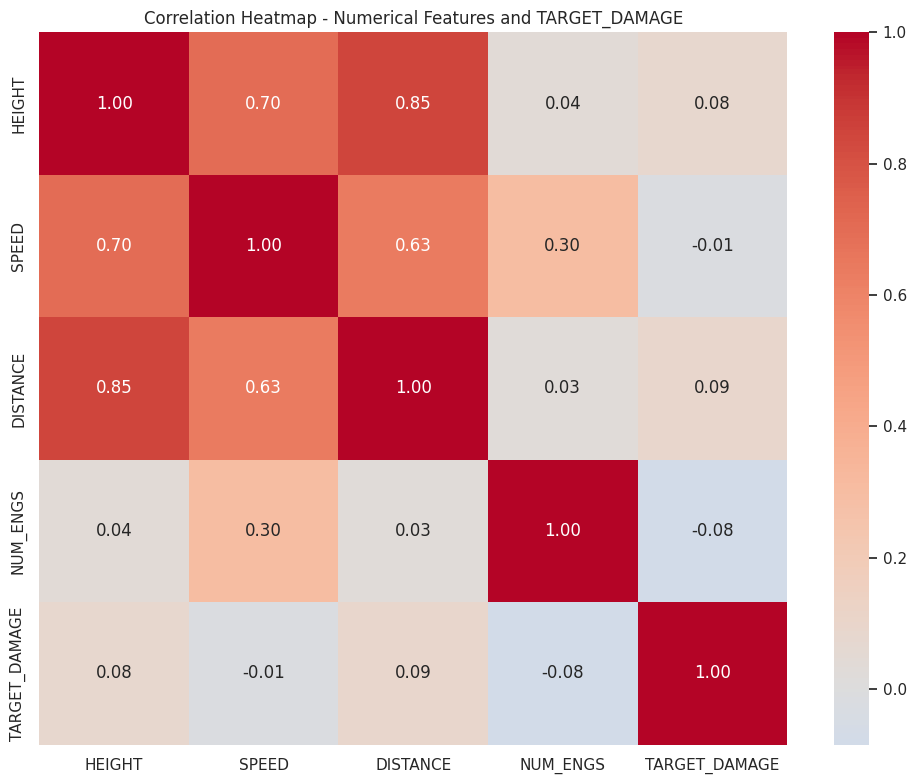

Correlation with TARGET_DAMAGE:
DISTANCE    0.093064
HEIGHT      0.084507
NUM_ENGS   -0.084409
SPEED      -0.012735
Saved -> figures/04_correlation_heatmap.png



In [ ]:

log("=" * 70)
log("STEP 5 - CORRELATION HEATMAP")
log("=" * 70)

corr_features = [
    "HEIGHT",
    "SPEED",
    "DISTANCE",
    "NUM_ENGS"
]

corr_features = [c for c in corr_features if c in df.columns]
corr_cols = corr_features + [TARGET]
corr = df[corr_cols].corr(numeric_only=True)


fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    ax=ax
)

ax.set_title(
    "Correlation Heatmap - Numerical Features and TARGET_DAMAGE"
)

plt.tight_layout()

plt.savefig(
    f"{FIG_DIR}/04_correlation_heatmap.png",
    dpi=120
)

plt.show()
plt.close()

target_corr = (
    corr[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

log("Correlation with TARGET_DAMAGE:")
log(target_corr.to_string())

log("Saved -> figures/04_correlation_heatmap.png")

log("")


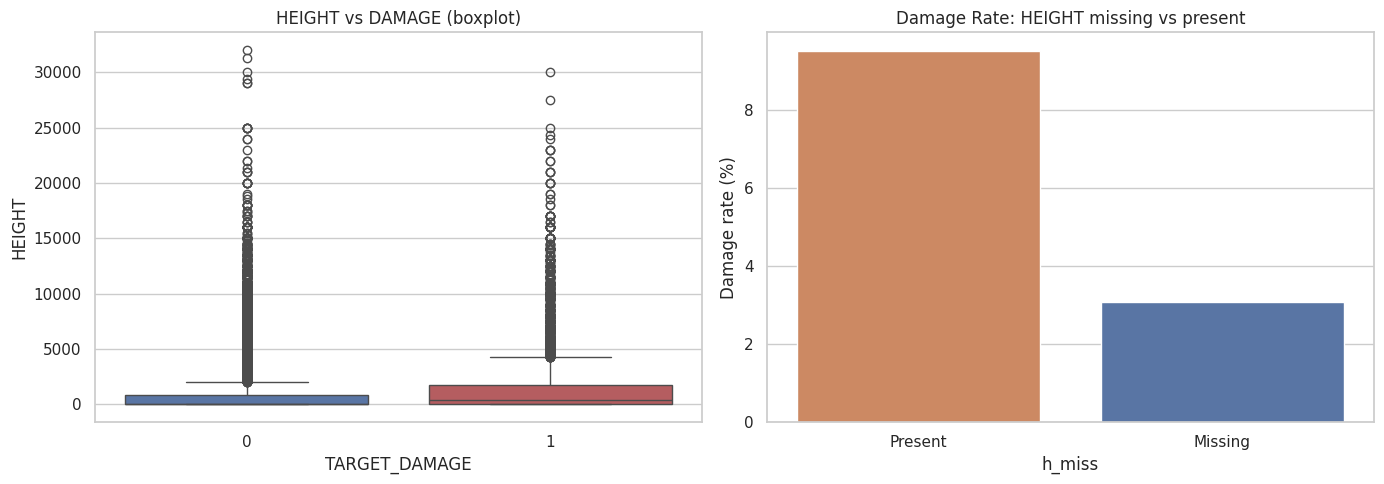

HEIGHT missing -> damage rate = 3.08% | HEIGHT present -> damage rate = 9.51%  (Person 1's pre-dedup figures: 3.1% / 9.5% -> same pattern)


In [ ]:
# --- HEIGHT vs DAMAGE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=TARGET, y="HEIGHT", data=df, ax=axes[0], hue=TARGET, palette=["#4C72B0", "#C44E52"], legend=False)
axes[0].set_title("HEIGHT vs DAMAGE (boxplot)")
h_missing_rate = df.assign(h_miss=df["HEIGHT"].isnull()).groupby("h_miss")[TARGET].mean() * 100
sns.barplot(x=h_missing_rate.index.map({True: "Missing", False: "Present"}),
            y=h_missing_rate.values, ax=axes[1], hue=h_missing_rate.index.map({True: "Missing", False: "Present"}),
            palette=["#DD8452", "#4C72B0"], legend=False)
axes[1].set_title("Damage Rate: HEIGHT missing vs present")
axes[1].set_ylabel("Damage rate (%)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_height_vs_damage.png", dpi=120)
plt.show()
plt.close()
log(f"HEIGHT missing -> damage rate = {h_missing_rate[True]:.2f}% | "
    f"HEIGHT present -> damage rate = {h_missing_rate[False]:.2f}%  "
    f"(Person 1's pre-dedup figures: 3.1% / 9.5% -> same pattern)")


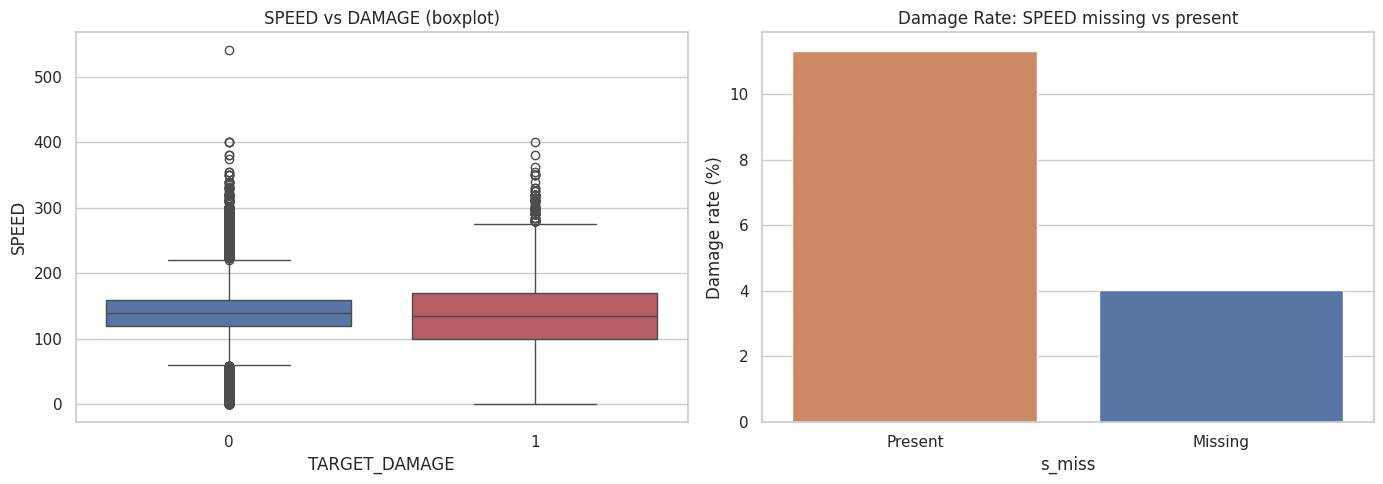

SPEED missing -> damage rate = 4.02% | SPEED present -> damage rate = 11.32%  (Person 1's pre-dedup figures: 4.0% / 11.3% -> same pattern)


In [ ]:
# --- SPEED vs DAMAGE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=TARGET, y="SPEED", data=df, ax=axes[0], hue=TARGET, palette=["#4C72B0", "#C44E52"], legend=False)
axes[0].set_title("SPEED vs DAMAGE (boxplot)")
s_missing_rate = df.assign(s_miss=df["SPEED"].isnull()).groupby("s_miss")[TARGET].mean() * 100
sns.barplot(x=s_missing_rate.index.map({True: "Missing", False: "Present"}),
            y=s_missing_rate.values, ax=axes[1], hue=s_missing_rate.index.map({True: "Missing", False: "Present"}),
            palette=["#DD8452", "#4C72B0"], legend=False)
axes[1].set_title("Damage Rate: SPEED missing vs present")
axes[1].set_ylabel("Damage rate (%)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_speed_vs_damage.png", dpi=120)
plt.show()
plt.close()
log(f"SPEED missing -> damage rate = {s_missing_rate[True]:.2f}% | "
    f"SPEED present -> damage rate = {s_missing_rate[False]:.2f}%  "
    f"(Person 1's pre-dedup figures: 4.0% / 11.3% -> same pattern)")

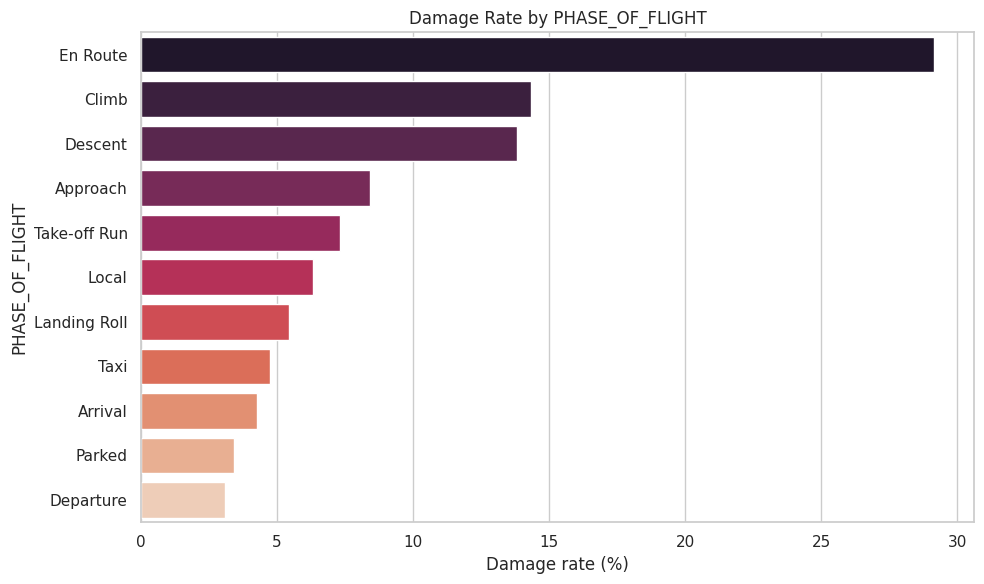

Damage rate by PHASE_OF_FLIGHT (top 3 highest-risk phases):
PHASE_OF_FLIGHT
En Route    29.16
Climb       14.34
Descent     13.83


In [ ]:
# --- PHASE_OF_FLIGHT vs DAMAGE ---
phase_damage = df.groupby("PHASE_OF_FLIGHT")[TARGET].agg(["mean", "count"])
phase_damage = phase_damage[phase_damage["count"] >= 100].sort_values("mean", ascending=False)
phase_damage["mean"] = phase_damage["mean"] * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=phase_damage["mean"], y=phase_damage.index, ax=ax, hue=phase_damage.index,
            palette="rocket", legend=False)
ax.set_title("Damage Rate by PHASE_OF_FLIGHT")
ax.set_xlabel("Damage rate (%)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_phase_of_flight_vs_damage.png", dpi=120)
plt.show()
plt.close()
log("Damage rate by PHASE_OF_FLIGHT (top 3 highest-risk phases):")
log(phase_damage["mean"].head(3).round(2).to_string())


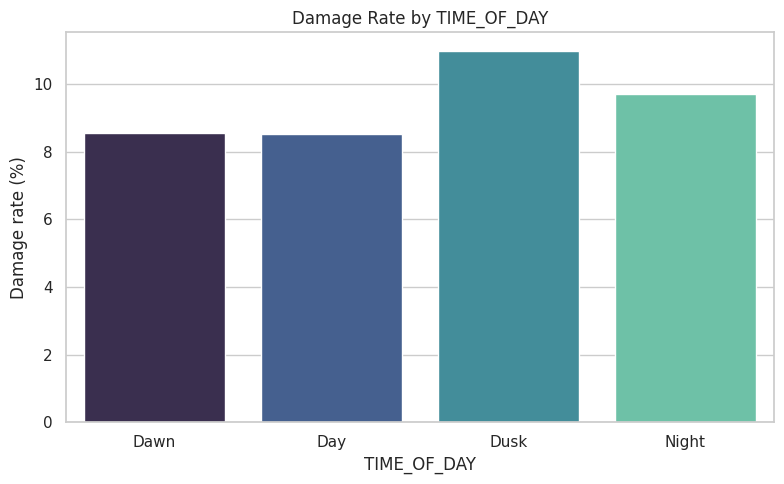

Damage rate by TIME_OF_DAY:
TIME_OF_DAY
Dawn      8.55
Day       8.54
Dusk     10.99
Night     9.73


In [ ]:
# --- TIME_OF_DAY vs DAMAGE ---
time_damage = df.groupby("TIME_OF_DAY")[TARGET].agg(["mean", "count"])
time_damage["mean"] = time_damage["mean"] * 100
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=time_damage.index, y=time_damage["mean"], ax=ax, hue=time_damage.index,
            palette="mako", legend=False)
ax.set_title("Damage Rate by TIME_OF_DAY")
ax.set_ylabel("Damage rate (%)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_time_of_day_vs_damage.png", dpi=120)
plt.show()
plt.close()
log(f"Damage rate by TIME_OF_DAY:\n{time_damage['mean'].round(2).to_string()}")

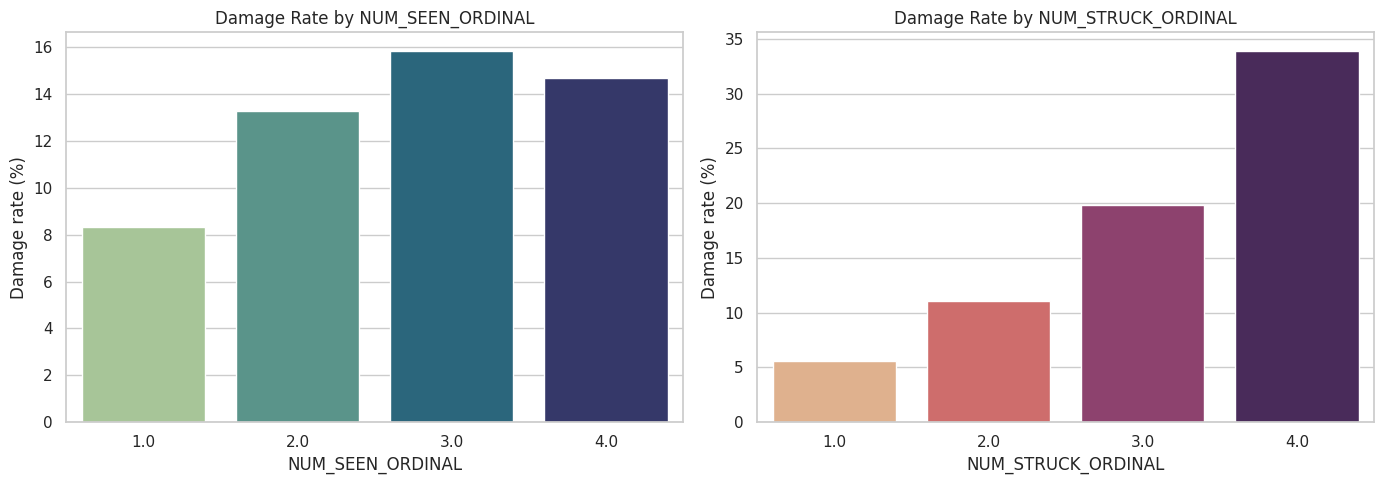

Damage rate rises with NUM_STRUCK_ORDINAL: 
NUM_STRUCK_ORDINAL
1.0     5.62
2.0    11.04
3.0    19.80
4.0    33.90


In [ ]:
# --- NUM_SEEN_ORDINAL / NUM_STRUCK_ORDINAL vs DAMAGE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
seen_damage = df.groupby("NUM_SEEN_ORDINAL")[TARGET].mean() * 100
sns.barplot(x=seen_damage.index, y=seen_damage.values, ax=axes[0], hue=seen_damage.index,
            palette="crest", legend=False)
axes[0].set_title("Damage Rate by NUM_SEEN_ORDINAL")
axes[0].set_ylabel("Damage rate (%)")

struck_damage = df.groupby("NUM_STRUCK_ORDINAL")[TARGET].mean() * 100
sns.barplot(x=struck_damage.index, y=struck_damage.values, ax=axes[1], hue=struck_damage.index,
            palette="flare", legend=False)
axes[1].set_title("Damage Rate by NUM_STRUCK_ORDINAL")
axes[1].set_ylabel("Damage rate (%)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/09_seen_struck_vs_damage.png", dpi=120)
plt.show()
plt.close()
log(f"Damage rate rises with NUM_STRUCK_ORDINAL: \n{struck_damage.round(2).to_string()}")


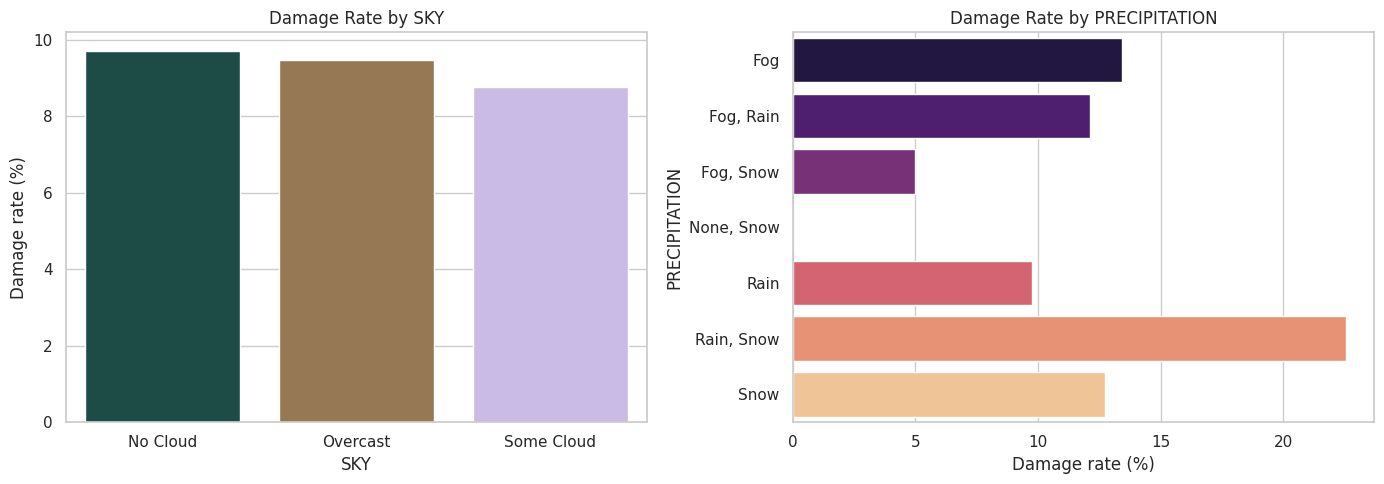

Damage rate by SKY:
SKY
No Cloud      9.70
Overcast      9.47
Some Cloud    8.77
Damage rate by PRECIPITATION (categories with >=20 rows):
PRECIPITATION
Fog           13.43
Fog, Rain     12.12
Fog, Snow      5.00
None, Snow     0.00
Rain           9.75
Rain, Snow    22.58
Snow          12.75

EDA COMPLETE

All figures saved in 'figures/' and conclusions saved in '/content/outputs/eda_conclusions.txt'


In [ ]:
# --- WEATHER (SKY + PRECIPITATION) vs DAMAGE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sky_damage = df.groupby("SKY")[TARGET].mean() * 100
sns.barplot(x=sky_damage.index, y=sky_damage.values, ax=axes[0], hue=sky_damage.index,
            palette="cubehelix", legend=False)
axes[0].set_title("Damage Rate by SKY")
axes[0].set_ylabel("Damage rate (%)")

precip_damage = df.groupby("PRECIPITATION")[TARGET].agg(["mean", "count"])
precip_damage = precip_damage[precip_damage["count"] >= 20]
precip_damage["mean"] = precip_damage["mean"] * 100
sns.barplot(x=precip_damage["mean"], y=precip_damage.index, ax=axes[1], hue=precip_damage.index,
            palette="magma", legend=False)
axes[1].set_title("Damage Rate by PRECIPITATION")
axes[1].set_xlabel("Damage rate (%)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/10_weather_vs_damage.png", dpi=120)
plt.show()
plt.close()
log(f"Damage rate by SKY:\n{sky_damage.round(2).to_string()}")
log(f"Damage rate by PRECIPITATION (categories with >=20 rows):\n{precip_damage['mean'].round(2).to_string()}")
log("")

log("=" * 70)
log("EDA COMPLETE")
log("=" * 70)

with open(f"{OUT_DIR}/eda_conclusions.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(conclusions))

print(f"\nAll figures saved in '{FIG_DIR}/' and conclusions saved in '{OUT_DIR}/eda_conclusions.txt'")

In [ ]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DATA_PATH = "cleaned_data.csv"
OUT_PATH = "engineered_data.csv"
FIG_DIR = "figures"
OUT_DIR = "outputs"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

TARGET = "TARGET_DAMAGE"

conclusions = []

def log(msg):
    print(msg)
    conclusions.append(msg)


In [ ]:
df = pd.read_csv("cleaned_data_no_duplicates.csv", low_memory=False)

print("Shape:", df.shape)
print("Duplicates:", df.duplicated().sum())
print("Target exists:", "TARGET_DAMAGE" in df.columns)

Shape: (354720, 63)
Duplicates: 0
Target exists: True


In [ ]:
log("=" * 70)
log("STEP 1 - SEASON (from INCIDENT_MONTH)")
log("=" * 70)

season_map = {12: "Winter", 1: "Winter", 2: "Winter",
              3: "Spring", 4: "Spring", 5: "Spring",
              6: "Summer", 7: "Summer", 8: "Summer",
              9: "Fall", 10: "Fall", 11: "Fall"}
df["SEASON"] = df["INCIDENT_MONTH"].map(season_map)

assert df["SEASON"].isna().sum() == 0, "SEASON has unmapped months!"
season_stats = df.groupby("SEASON")[TARGET].agg(["mean", "count"]).sort_values("mean", ascending=False)
log("Damage rate by SEASON (verified on the real data):")
log(str(season_stats))
log("-> Highest season: " + season_stats.index[0] + f" ({season_stats['mean'].iloc[0]*100:.1f}%)  |  lowest: "
    + season_stats.index[-1] + f" ({season_stats['mean'].iloc[-1]*100:.1f}%)  |  all: "
    + ", ".join(f"{k}={v*100:.1f}%" for k, v in season_stats["mean"].items()))
log("")


STEP 1 - SEASON (from INCIDENT_MONTH)
Damage rate by SEASON (verified on the real data):
            mean   count
SEASON                  
Winter  0.105185   35832
Spring  0.071355   80177
Fall    0.068202  113897
Summer  0.039955  124814
-> Highest season: Winter (10.5%)  |  lowest: Summer (4.0%)  |  all: Winter=10.5%, Spring=7.1%, Fall=6.8%, Summer=4.0%



In [ ]:

log("=" * 70)
log("STEP 2 - HOUR (from TIME)")
log("=" * 70)

def parse_hour(t):
    if pd.isna(t):
        return np.nan
    t = str(t).strip()
    if t == "" or ":" not in t:
        return np.nan
    try:
        return int(t.split(":")[0])
    except ValueError:
        return np.nan

df["HOUR"] = df["TIME"].apply(parse_hour)

n_missing_time = df["TIME"].isna().sum() + (df["TIME"].astype(str).str.strip() == "").sum()
n_missing_hour = df["HOUR"].isna().sum()
log(f"TIME missing/blank (raw): {n_missing_time} | HOUR missing after parsing: {n_missing_hour}")
log(f"HOUR range: {df['HOUR'].min()} - {df['HOUR'].max()} (should be 0-23)")
assert df["HOUR"].dropna().between(0, 23).all(), "HOUR has out-of-range values!"
log("")



STEP 2 - HOUR (from TIME)
TIME missing/blank (raw): 152378 | HOUR missing after parsing: 152378
HOUR range: 0.0 - 23.0 (should be 0-23)



In [ ]:
log("=" * 70)
log("STEP 3 - PHASE_RISK_GROUP (from PHASE_OF_FLIGHT)")
log("=" * 70)

phase_rate = df.groupby("PHASE_OF_FLIGHT")[TARGET].mean().sort_values(ascending=False)
log("Damage rate per PHASE_OF_FLIGHT (re-verified on the de-duplicated data):")
log(str(phase_rate))

HIGH_RISK_PHASES = {"En Route", "Climb", "Descent", "Unknown"}
MED_RISK_PHASES = {"Approach", "Take-off Run", "Local"}
LOW_RISK_PHASES = {"Landing Roll", "Taxi", "Arrival", "Parked", "Departure"}

def phase_risk(p):
    if pd.isna(p):
        return "Missing"
    if p in HIGH_RISK_PHASES:
        return "High"
    if p in MED_RISK_PHASES:
        return "Medium"
    if p in LOW_RISK_PHASES:
        return "Low"
    return "Missing"

df["PHASE_RISK_GROUP"] = df["PHASE_OF_FLIGHT"].apply(phase_risk)

STEP 3 - PHASE_RISK_GROUP (from PHASE_OF_FLIGHT)
Damage rate per PHASE_OF_FLIGHT (re-verified on the de-duplicated data):
PHASE_OF_FLIGHT
En Route        0.291634
Climb           0.143362
Unknown         0.142857
Descent         0.138288
Approach        0.084198
Take-off Run    0.073299
Local           0.063307
Landing Roll    0.054260
Taxi            0.047509
Arrival         0.042518
Parked          0.034188
Departure       0.031082
Name: TARGET_DAMAGE, dtype: float64


In [ ]:
known = HIGH_RISK_PHASES | MED_RISK_PHASES | LOW_RISK_PHASES
unaccounted = set(df["PHASE_OF_FLIGHT"].dropna().unique()) - known
assert not unaccounted, f"Unaccounted PHASE_OF_FLIGHT categories: {unaccounted}"

grp_stats = df.groupby("PHASE_RISK_GROUP")[TARGET].agg(["mean", "count"]).sort_values("mean", ascending=False)
log("Damage rate by PHASE_RISK_GROUP:")
log(str(grp_stats))
n_unknown = int((df["PHASE_OF_FLIGHT"] == "Unknown").sum())
unk_rate = df.loc[df["PHASE_OF_FLIGHT"] == "Unknown", TARGET].mean() * 100
log(f"-> Note: 'Unknown' ({n_unknown} rows only) was grouped into High based on its raw rate ({unk_rate:.1f}%,")
log("   same order as Climb/Descent), but the sample is too tiny to be meaningful on its own.")
miss_share = df["PHASE_OF_FLIGHT"].isna().mean() * 100
miss_rate = df.loc[df["PHASE_OF_FLIGHT"].isna(), TARGET].mean() * 100
log(f"-> 'Missing' ({miss_share:.1f}% of rows, PHASE_OF_FLIGHT not reported) has the LOWEST damage rate ({miss_rate:.1f}%)")
log("   -- consistent with Person 1's earlier finding that missingness itself carries signal")
log("   (unreported/minor incidents tend to have less-detailed reports).")
log("")

Damage rate by PHASE_RISK_GROUP:
                      mean   count
PHASE_RISK_GROUP                  
High              0.166288   40983
Medium            0.080918  128476
Low               0.051600   45756
Missing           0.019161  139505
-> Note: 'Unknown' (7 rows only) was grouped into High based on its raw rate (14.3%,
   same order as Climb/Descent), but the sample is too tiny to be meaningful on its own.
-> 'Missing' (39.3% of rows, PHASE_OF_FLIGHT not reported) has the LOWEST damage rate (1.9%)
   -- consistent with Person 1's earlier finding that missingness itself carries signal
   (unreported/minor incidents tend to have less-detailed reports).



In [ ]:
log("=" * 70)
log("STEP 4 - HEIGHT_CATEGORY (from HEIGHT)")
log("=" * 70)

height_bins = [-0.1, 0, 500, 3000, np.inf]
height_labels = ["Ground", "Low", "Medium", "High"]
df["HEIGHT_CATEGORY"] = pd.cut(df["HEIGHT"], bins=height_bins, labels=height_labels)
df["HEIGHT_CATEGORY"] = df["HEIGHT_CATEGORY"].astype(object)
df.loc[df["HEIGHT"].isna(), "HEIGHT_CATEGORY"] = "Missing"

height_stats = df.groupby("HEIGHT_CATEGORY", observed=False)[TARGET].agg(["mean", "count"])
log("Bins: Ground(=0ft) | Low(0-500ft) | Medium(500-3000ft) | High(>3000ft) | Missing")
log("Damage rate by HEIGHT_CATEGORY (re-verified on real data):")
log(str(height_stats.sort_values("mean", ascending=False)))
h = height_stats["mean"] * 100
log(f"-> Damage rate: Ground({h['Ground']:.1f}%) -> Low({h['Low']:.1f}%) -> Medium({h['Medium']:.1f}%) -> High({h['High']:.1f}%)"
    f" | Missing({h['Missing']:.1f}%).")
log("   Grouping is directionally sound if High/Medium stay far above Ground/Low (see numbers above).")
log("")


STEP 4 - HEIGHT_CATEGORY (from HEIGHT)
Bins: Ground(=0ft) | Low(0-500ft) | Medium(500-3000ft) | High(>3000ft) | Missing
Damage rate by HEIGHT_CATEGORY (re-verified on real data):
                     mean   count
HEIGHT_CATEGORY                  
Medium           0.150495   36546
High             0.137622   14736
Low              0.090488   48846
Ground           0.063116   76066
Missing          0.030785  178526
-> Damage rate: Ground(6.3%) -> Low(9.0%) -> Medium(15.0%) -> High(13.8%) | Missing(3.1%).
   Grouping is directionally sound if High/Medium stay far above Ground/Low (see numbers above).



In [ ]:
log("=" * 70)
log("STEP 5 - SPEED_CATEGORY (from SPEED)")
log("=" * 70)

speed_bins = [-0.1, 100, 160, 250, np.inf]
speed_labels = ["Slow", "Moderate", "Fast", "VeryFast"]
df["SPEED_CATEGORY"] = pd.cut(df["SPEED"], bins=speed_bins, labels=speed_labels)
df["SPEED_CATEGORY"] = df["SPEED_CATEGORY"].astype(object)
df.loc[df["SPEED"].isna(), "SPEED_CATEGORY"] = "Missing"

speed_stats = df.groupby("SPEED_CATEGORY", observed=False)[TARGET].agg(["mean", "count"])
log("Bins: Slow(<100kt) | Moderate(100-160kt) | Fast(160-250kt) | VeryFast(>250kt) | Missing")
log("Damage rate by SPEED_CATEGORY (re-verified on real data):")
log(str(speed_stats.sort_values("mean", ascending=False)))
sp = speed_stats["mean"] * 100
log(f"-> Slow={sp['Slow']:.1f}%, Moderate={sp['Moderate']:.1f}%, Fast={sp['Fast']:.1f}%, VeryFast={sp['VeryFast']:.1f}%, Missing={sp['Missing']:.1f}%")
if not (sp["Slow"] < sp["Moderate"] < sp["Fast"] < sp["VeryFast"]):
    log("   NOT monotonic: a real U-shape in the data, not a bug. Documented as-is; worth flagging to")
    log("   Person 3 that SPEED_CATEGORY may need non-linear models to exploit properly.")
log("")

STEP 5 - SPEED_CATEGORY (from SPEED)
Bins: Slow(<100kt) | Moderate(100-160kt) | Fast(160-250kt) | VeryFast(>250kt) | Missing
Damage rate by SPEED_CATEGORY (re-verified on real data):
                    mean   count
SPEED_CATEGORY                  
VeryFast        0.261250     800
Slow            0.161188   19772
Fast            0.126932   25360
Moderate        0.090853   63586
Missing         0.040183  245202
-> Slow=16.1%, Moderate=9.1%, Fast=12.7%, VeryFast=26.1%, Missing=4.0%
   NOT monotonic: a real U-shape in the data, not a bug. Documented as-is; worth flagging to
   Person 3 that SPEED_CATEGORY may need non-linear models to exploit properly.



In [ ]:
df["MULTIPLE_BIRDS_STRUCK"] = np.where(
    df["NUM_STRUCK_ORDINAL"].notna(),
    (df["NUM_STRUCK_ORDINAL"] > 1).astype(int),
    np.nan
)

df["SEEN_COUNT_REPORTED"] = (
    df["NUM_SEEN_ORDINAL"].notna().astype(int)
)

In [ ]:
df["IS_SINGLE_ENGINE"] = np.where(
    df["NUM_ENGS"].notna(),
    (df["NUM_ENGS"] == 1).astype(int),
    np.nan
)

df["SMALL_AIRCRAFT_MASS"] = np.where(
    df["AC_MASS"].notna(),
    df["AC_MASS"].isin([1, 2]).astype(int),
    np.nan
)

In [ ]:
log("=" * 70)
log("STEP 8 - PRECIPITATION simple flags (IS_FOG / IS_RAIN / IS_SNOW)")
log("=" * 70)

precip = df["PRECIPITATION"].fillna("")
df["IS_FOG"] = precip.str.contains("Fog").astype(int)
df["IS_RAIN"] = precip.str.contains("Rain").astype(int)
df["IS_SNOW"] = precip.str.contains("Snow").astype(int)

for flag in ["IS_FOG", "IS_RAIN", "IS_SNOW"]:
    s = df.groupby(flag)[TARGET].agg(["mean", "count"])
    log(f"Damage rate by {flag}:")
    log(str(s))
log("These are PLAIN 0/1 flags only -- Person 1 still owns PRECIPITATION itself for")
log("any further Encoding/Scaling, as agreed.")
log("")


STEP 8 - PRECIPITATION simple flags (IS_FOG / IS_RAIN / IS_SNOW)
Damage rate by IS_FOG:
            mean   count
IS_FOG                  
0       0.062087  351556
1       0.132111    3164
Damage rate by IS_RAIN:
             mean   count
IS_RAIN                  
0        0.061735  345380
1        0.098822    9340
Damage rate by IS_SNOW:
             mean   count
IS_SNOW                  
0        0.062582  354000
1        0.126389     720
These are PLAIN 0/1 flags only -- Person 1 still owns PRECIPITATION itself for
any further Encoding/Scaling, as agreed.



NameError: name 'order_h' is not defined

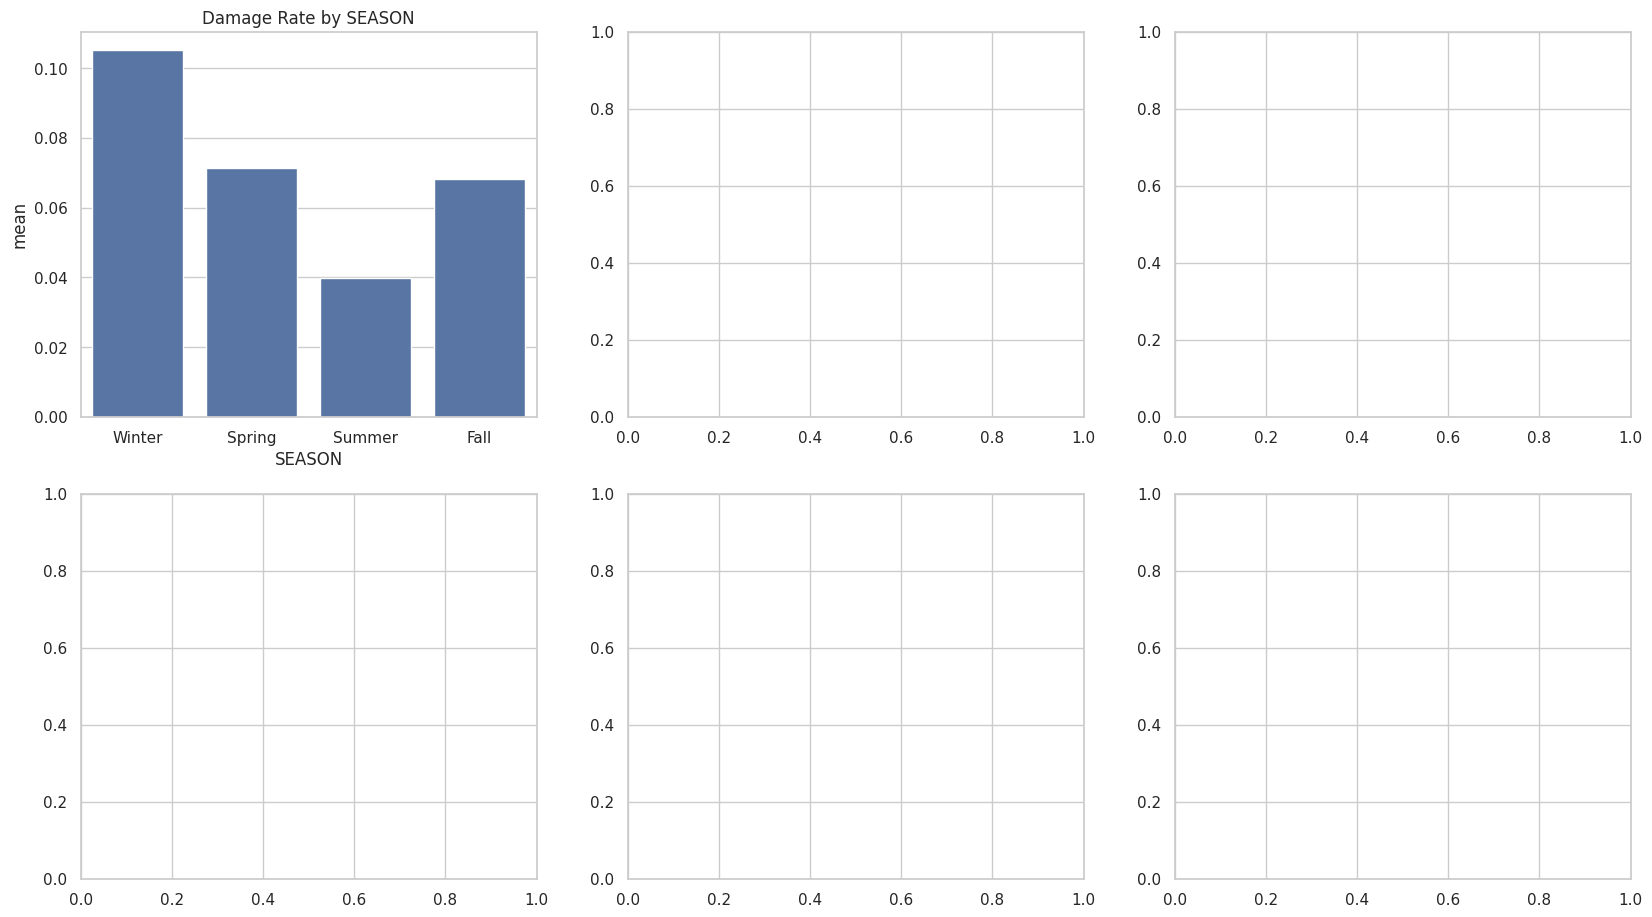

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
sns.barplot(
    x=season_stats.index,
    y=season_stats["mean"],
    ax=axes[0, 0],
    order=["Winter", "Spring", "Summer", "Fall"],
    color="#4C72B0"
)
axes[0, 0].set_title("Damage Rate by SEASON")

sns.barplot(
    x=order_h,
    y=height_stats.loc[order_h, "mean"],
    ax=axes[0, 1],
    color="#55A868"
)
axes[0, 1].set_title("Damage Rate by HEIGHT_CATEGORY")

sns.barplot(
    x=order_s,
    y=speed_stats.loc[order_s, "mean"],
    ax=axes[0, 2],
    color="#C44E52"
)
axes[0, 2].set_title("Damage Rate by SPEED_CATEGORY")

axes[1, 1].axis("off")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
log("=" * 70)
log("STEP 10 - SAVE engineered_data.csv")
log("=" * 70)

new_cols = [
    "SEASON",
    "HOUR",
    "HEIGHT_CATEGORY",
    "SPEED_CATEGORY",
    "MULTIPLE_BIRDS_STRUCK",
    "SEEN_COUNT_REPORTED",
    "IS_SINGLE_ENGINE",
    "SMALL_AIRCRAFT_MASS",
    "IS_FOG",
    "IS_RAIN",
    "IS_SNOW"
]

original_cols = pd.read_csv(
    DATA_PATH,
    low_memory=False,
    nrows=0
).columns.tolist()

n_cols_before = len(original_cols)

assert all(
    c in df.columns for c in original_cols
), "An original column went missing!"

assert df.shape[0] == 354720, \
    "Row count changed during feature engineering!"

df.to_csv(OUT_PATH, index=False)

log(
    f"Saved -> {OUT_PATH} | "
    f"final shape: {df.shape}"
)

log(f"New columns added: {new_cols}")

with open(
    f"{OUT_DIR}/feature_engineering_summary.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write("\n".join(conclusions))

log("Saved -> outputs/feature_engineering_summary.txt")

STEP 10 - SAVE engineered_data.csv
Saved -> engineered_data.csv | final shape: (354720, 75)
New columns added: ['SEASON', 'HOUR', 'HEIGHT_CATEGORY', 'SPEED_CATEGORY', 'MULTIPLE_BIRDS_STRUCK', 'SEEN_COUNT_REPORTED', 'IS_SINGLE_ENGINE', 'SMALL_AIRCRAFT_MASS', 'IS_FOG', 'IS_RAIN', 'IS_SNOW']
Saved -> outputs/feature_engineering_summary.txt


In [ ]:
# هنبدا نبني المودلين اللي معانا
df = pd.read_csv("engineered_data.csv", low_memory=False)
print(f"engineered_data.csv shape: {df.shape}")

TARGET = "TARGET_DAMAGE"

engineered_data.csv shape: (354720, 75)


In [ ]:
CORE_FEATURES_V2 = [
    # -- original 18 core features (PRECIPITATION dropped, superseded) --
    "AC_CLASS", "AC_MASS", "TYPE_ENG", "NUM_ENGS",
    "PHASE_OF_FLIGHT", "HEIGHT", "SPEED", "DISTANCE",
    "TIME_OF_DAY", "SKY",
    "INCIDENT_MONTH", "INCIDENT_YEAR",
    "STATE", "FAAREGION",
    "SPECIES", "SIZE", "NUM_SEEN_ORDINAL", "NUM_STRUCK_ORDINAL",
    # -- 13 new engineered columns
    "SEASON", "HOUR", "PHASE_RISK_GROUP", "HEIGHT_CATEGORY", "SPEED_CATEGORY",
    "MULTIPLE_BIRDS_STRUCK", "SEEN_COUNT_REPORTED", "SEEN_STRUCK_RATIO",
    "IS_SINGLE_ENGINE", "SMALL_AIRCRAFT_MASS", "IS_FOG", "IS_RAIN", "IS_SNOW",
]

In [ ]:
OPTIONAL_STRIKE_FEATURES = [c for c in df.columns if c.startswith("STR_") or c.startswith("ING_")] + [
    "INGESTED_OTHER"
]

print(f"\nCORE_FEATURES_V2 ({len(CORE_FEATURES_V2)}): {CORE_FEATURES_V2}")
print(f"\nOPTIONAL_STRIKE_FEATURES ({len(OPTIONAL_STRIKE_FEATURES)}): {OPTIONAL_STRIKE_FEATURES}")



CORE_FEATURES_V2 (31): ['AC_CLASS', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SPEED', 'DISTANCE', 'TIME_OF_DAY', 'SKY', 'INCIDENT_MONTH', 'INCIDENT_YEAR', 'STATE', 'FAAREGION', 'SPECIES', 'SIZE', 'NUM_SEEN_ORDINAL', 'NUM_STRUCK_ORDINAL', 'SEASON', 'HOUR', 'PHASE_RISK_GROUP', 'HEIGHT_CATEGORY', 'SPEED_CATEGORY', 'MULTIPLE_BIRDS_STRUCK', 'SEEN_COUNT_REPORTED', 'SEEN_STRUCK_RATIO', 'IS_SINGLE_ENGINE', 'SMALL_AIRCRAFT_MASS', 'IS_FOG', 'IS_RAIN', 'IS_SNOW']

OPTIONAL_STRIKE_FEATURES (19): ['STR_RAD', 'STR_WINDSHLD', 'STR_NOSE', 'STR_ENG1', 'ING_ENG1', 'STR_ENG2', 'ING_ENG2', 'STR_ENG3', 'ING_ENG3', 'STR_ENG4', 'ING_ENG4', 'STR_PROP', 'STR_WING_ROT', 'STR_FUSE', 'STR_LG', 'STR_TAIL', 'STR_LGHTS', 'STR_OTHER', 'INGESTED_OTHER']


In [ ]:
CORE_FEATURES_V2.remove("SEEN_STRUCK_RATIO")

In [ ]:
# Verify engineered precipitation features
manual_rain = df["PRECIPITATION"].str.contains("Rain", na=False).astype(int)
manual_fog = df["PRECIPITATION"].str.contains("Fog", na=False).astype(int)
manual_snow = df["PRECIPITATION"].str.contains("Snow", na=False).astype(int)

assert (manual_rain == df["IS_RAIN"]).all(), \
    "IS_RAIN does not match PRECIPITATION!"

assert (manual_fog == df["IS_FOG"]).all(), \
    "IS_FOG does not match PRECIPITATION!"

assert (manual_snow == df["IS_SNOW"]).all(), \
    "IS_SNOW does not match PRECIPITATION!"

print(
    "\nConfirmed: IS_FOG / IS_RAIN / IS_SNOW "
    "exactly match PRECIPITATION."
)
MODEL_B_FEATURES = CORE_FEATURES_V2 + OPTIONAL_STRIKE_FEATURES

model_data_b = df[MODEL_B_FEATURES + [TARGET]].copy()

model_data_b.to_csv(
    "model_data_B_v2.csv",
    index=False
)

print(f"\nSaved model_data_B_v2.csv: {model_data_b.shape}")
print(f"Number of features: {len(MODEL_B_FEATURES)}")

print("\nModel B features:")
print(MODEL_B_FEATURES)


Confirmed: IS_FOG / IS_RAIN / IS_SNOW exactly match PRECIPITATION.

Saved model_data_B_v2.csv: (354720, 50)
Number of features: 49

Model B features:
['AC_CLASS', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SPEED', 'DISTANCE', 'TIME_OF_DAY', 'SKY', 'INCIDENT_MONTH', 'INCIDENT_YEAR', 'STATE', 'FAAREGION', 'SPECIES', 'SIZE', 'NUM_SEEN_ORDINAL', 'NUM_STRUCK_ORDINAL', 'SEASON', 'HOUR', 'PHASE_RISK_GROUP', 'HEIGHT_CATEGORY', 'SPEED_CATEGORY', 'MULTIPLE_BIRDS_STRUCK', 'SEEN_COUNT_REPORTED', 'IS_SINGLE_ENGINE', 'SMALL_AIRCRAFT_MASS', 'IS_FOG', 'IS_RAIN', 'IS_SNOW', 'STR_RAD', 'STR_WINDSHLD', 'STR_NOSE', 'STR_ENG1', 'ING_ENG1', 'STR_ENG2', 'ING_ENG2', 'STR_ENG3', 'ING_ENG3', 'STR_ENG4', 'ING_ENG4', 'STR_PROP', 'STR_WING_ROT', 'STR_FUSE', 'STR_LG', 'STR_TAIL', 'STR_LGHTS', 'STR_OTHER', 'INGESTED_OTHER']


In [ ]:
CATEGORICAL_COLS = [
    "AC_CLASS", "TYPE_ENG", "PHASE_OF_FLIGHT", "TIME_OF_DAY", "SKY",
    "STATE", "FAAREGION", "SPECIES", "SIZE",
]
CONTINUOUS_GROUPED_BY_PHASE = ["HEIGHT", "SPEED", "DISTANCE"]
ORDINAL_BY_ACCLASS_COLS = ["AC_MASS", "NUM_ENGS"]


In [ ]:
def group_impute(series: pd.Series, group_key: pd.Series, stat: str) -> pd.Series:
    if stat == "median":
        group_value = series.groupby(group_key).transform("median")
        overall = series.median()
    else:  # mode
        group_value = series.groupby(group_key).transform(
            lambda s: s.mode().iloc[0] if not s.mode().empty else pd.NA
        )
        overall = series.mode().iloc[0]
    return series.fillna(group_value).fillna(overall)

In [ ]:
def impute(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # --- Missingness indicators BEFORE any filling ------------------------
    for col in CONTINUOUS_GROUPED_BY_PHASE + ["HOUR"]:
        df[f"{col}_WAS_MISSING"] = df[col].isna().astype(int)

    # --- Group-based imputation, using RAW grouping columns ---------------
    for col in ORDINAL_BY_ACCLASS_COLS:
        df[col] = group_impute(df[col], df["AC_CLASS"], stat="mode")

    for col in CONTINUOUS_GROUPED_BY_PHASE:
        df[col] = group_impute(df[col], df["PHASE_OF_FLIGHT"], stat="median")

    df["HOUR"] = group_impute(df["HOUR"], df["TIME_OF_DAY"], stat="median")


    # --- Categorical columns: missing -> explicit "Missing" category ------
    for col in CATEGORICAL_COLS:
        df[col] = df[col].fillna("Missing")

    # --- NUM_SEEN_ORDINAL: missing = its own "not reported" level (0) -----
    df["NUM_SEEN_ORDINAL"] = df["NUM_SEEN_ORDINAL"].fillna(0)

    # --- NUM_STRUCK_ORDINAL: trivial missing -> overall mode --------------
    df["NUM_STRUCK_ORDINAL"] = df["NUM_STRUCK_ORDINAL"].fillna(
        df["NUM_STRUCK_ORDINAL"].mode().iloc[0]
    )

    return df

In [ ]:
name = "model_data_B_v2"
raw = pd.read_csv(
    f"{name}.csv",
    low_memory=False
)

cleaned = impute(raw)
remaining = cleaned.isna().sum().sum()

print(
    f"{name}: shape {cleaned.shape}, "
    f"remaining missing values: {remaining}"
)

out_path = f"{name}_imputed.csv"
cleaned.to_csv(
    out_path,
    index=False
)
print(f"  -> saved {out_path}")

/tmp/ipykernel_1260/2502212204.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return series.fillna(group_value).fillna(overall)


model_data_B_v2: shape (354720, 54), remaining missing values: 200246
  -> saved model_data_B_v2_imputed.csv


In [ ]:
RANDOM_STATE = 42

ONE_HOT_COLS = [
    "AC_CLASS",
    "TYPE_ENG",
    "PHASE_OF_FLIGHT",
    "TIME_OF_DAY",
    "SKY",
    "FAAREGION",
    "SEASON",
]

TARGET_ENCODE_COLS = [
    "STATE",
    "SPECIES"
]

SIZE_MAP = {
    "Missing": 0,
    "Small": 1,
    "Medium": 2,
    "Large": 3
}

HEIGHT_CAT_MAP = {
    "Missing": 0,
    "Ground": 1,
    "Low": 2,
    "Medium": 3,
    "High": 4
}

SPEED_CAT_MAP = {
    "Missing": 0,
    "Slow": 1,
    "Moderate": 2,
    "Fast": 3,
    "VeryFast": 4
}

ORDINAL_MAPS = {
    "SIZE": ("SIZE_ORDINAL", SIZE_MAP),
    "HEIGHT_CATEGORY": ("HEIGHT_CATEGORY_ORDINAL", HEIGHT_CAT_MAP),
    "SPEED_CATEGORY": ("SPEED_CATEGORY_ORDINAL", SPEED_CAT_MAP),
}

SCALE_COLS_BASE = [
    "HEIGHT",
    "SPEED",
    "DISTANCE",
    "HOUR"
]

In [ ]:
from sklearn.model_selection import StratifiedKFold

def kfold_target_encode(col_train, y_train, n_splits=5, smoothing=10):
    global_mean = y_train.mean()
    oof = pd.Series(index=col_train.index, dtype=float)
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    for fit_idx, hold_idx in skf.split(col_train, y_train):
        fit_col = col_train.iloc[fit_idx]
        fit_y = y_train.iloc[fit_idx]

        stats = fit_y.groupby(fit_col).agg(["mean", "count"])

        smoothed = (
            stats["mean"] * stats["count"]
            + global_mean * smoothing
        ) / (
            stats["count"] + smoothing
        )

        oof.iloc[hold_idx] = (
            col_train.iloc[hold_idx]
            .map(smoothed)
            .fillna(global_mean)
            .values
        )

    full_stats = y_train.groupby(col_train).agg(["mean", "count"])

    full_mapping = (
        full_stats["mean"] * full_stats["count"]
        + global_mean * smoothing
    ) / (
        full_stats["count"] + smoothing
    )

    return oof, full_mapping, global_mean

In [ ]:
name = "model_data_B_v2_imputed"

df = pd.read_csv(
    f"{name}.csv",
    low_memory=False
)

obj_cols = df.select_dtypes(include=["object", "string"]).columns
df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())

# --- Ordinal encodings ---
for raw_col, (new_col, mapping) in ORDINAL_MAPS.items():
    df[new_col] = df[raw_col].map(mapping)
    df = df.drop(columns=[raw_col])

# Separate target and features
y = df["TARGET_DAMAGE"]
X = df.drop(columns=["TARGET_DAMAGE"])

# 70% Train, 15% Validation, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Model B split:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Model B split:
Train: (248304, 53)
Validation: (53208, 53)
Test: (53208, 53)


In [ ]:
# --- One-Hot: fit categories on train, align test to the same columns
X_train = pd.get_dummies(X_train, columns=ONE_HOT_COLS, dtype=int)
X_test = pd.get_dummies(X_test, columns=ONE_HOT_COLS, dtype=int)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


In [ ]:
te_maps = {}
for col in TARGET_ENCODE_COLS:
    oof_values, full_mapping, global_mean = kfold_target_encode(X_train[col], y_train)
    X_train[f"{col}_TE"] = oof_values
    X_test[f"{col}_TE"] = X_test[col].map(full_mapping).fillna(global_mean)
    X_train = X_train.drop(columns=[col])
    X_test = X_test.drop(columns=[col])
    te_maps[col] = {"mapping": full_mapping, "global_mean": global_mean}


In [ ]:
scale_cols = SCALE_COLS_BASE + [f"{c}_TE" for c in TARGET_ENCODE_COLS]
scaler = RobustScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [ ]:
# Save processed datasets
X_train.to_csv(f"{name}_X_train.csv", index=False)
X_val.to_csv(f"{name}_X_val.csv", index=False)
X_test.to_csv(f"{name}_X_test.csv", index=False)

y_train.to_csv(f"{name}_y_train.csv", index=False)
y_val.to_csv(f"{name}_y_val.csv", index=False)
y_test.to_csv(f"{name}_y_test.csv", index=False)

# Save preprocessing objects
joblib.dump(scaler, f"{name}_scaler.joblib")
joblib.dump(te_maps, f"{name}_target_encoding_maps.joblib")

# Print information
print(f"{name}:")
print(f"  X_train {X_train.shape}")
print(f"  X_val   {X_val.shape}")
print(f"  X_test  {X_test.shape}")

print(f"  y_train damage rate: {y_train.mean():.4f}")
print(f"  y_val damage rate:   {y_val.mean():.4f}")
print(f"  y_test damage rate:  {y_test.mean():.4f}\n")

model_data_B_v2_imputed:
  X_train (248304, 97)
  X_val   (53208, 53)
  X_test  (53208, 97)
  y_train damage rate: 0.0627
  y_val damage rate:   0.0627
  y_test damage rate:  0.0627



بداية الكووووود ال models

In [ ]:
import warnings, gc, time, json
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (log_loss, accuracy_score, f1_score, precision_score, recall_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              classification_report, precision_recall_curve)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
TARGET = 'TARGET_DAMAGE'
print('xgboost available:', HAS_XGB, '| lightgbm available:', HAS_LGBM)

xgboost available: True | lightgbm available: True


In [ ]:
df = pd.read_csv(
    "engineered_data.csv",
    low_memory=False
)

print(f"engineered_data.csv shape: {df.shape}")

CORE_FEATURES_V2 = [
    "AC_CLASS",
    "AC_MASS",
    "TYPE_ENG",
    "NUM_ENGS",
    "PHASE_OF_FLIGHT",
    "HEIGHT",
    "SPEED",
    "DISTANCE",
    "TIME_OF_DAY",
    "SKY",
    "INCIDENT_MONTH",
    "INCIDENT_YEAR",
    "STATE",
    "FAAREGION",
    "SPECIES",
    "SIZE",
    "NUM_SEEN_ORDINAL",
    "NUM_STRUCK_ORDINAL",
    "SEASON",
    "HOUR",
    "HEIGHT_CATEGORY",
    "SPEED_CATEGORY",
    "MULTIPLE_BIRDS_STRUCK",
    "SEEN_COUNT_REPORTED",
    "IS_SINGLE_ENGINE",
    "SMALL_AIRCRAFT_MASS",
    "IS_FOG",
    "IS_RAIN",
    "IS_SNOW",
]

OPTIONAL_STRIKE_FEATURES = [
    c for c in df.columns
    if c.startswith("STR_") or c.startswith("ING_")
]

print(
    f"OPTIONAL_STRIKE_FEATURES ({len(OPTIONAL_STRIKE_FEATURES)}): "
    f"{OPTIONAL_STRIKE_FEATURES}"
)

manual_rain = df["PRECIPITATION"].str.contains(
    "Rain", na=False
).astype(int)

manual_fog = df["PRECIPITATION"].str.contains(
    "Fog", na=False
).astype(int)

manual_snow = df["PRECIPITATION"].str.contains(
    "Snow", na=False
).astype(int)

assert (manual_rain == df["IS_RAIN"]).all(), \
    "IS_RAIN does not match PRECIPITATION!"

assert (manual_fog == df["IS_FOG"]).all(), \
    "IS_FOG does not match PRECIPITATION!"

assert (manual_snow == df["IS_SNOW"]).all(), \
    "IS_SNOW does not match PRECIPITATION!"

print(
    "Confirmed: IS_FOG / IS_RAIN / IS_SNOW "
    "match PRECIPITATION."
)

MODEL_B_FEATURES = CORE_FEATURES_V2 + OPTIONAL_STRIKE_FEATURES

model_data_b = df[
    MODEL_B_FEATURES + [TARGET]
].copy()

print(f"model_data_B_v2 shape: {model_data_b.shape}")
print(f"Number of features: {len(MODEL_B_FEATURES)}")

engineered_data.csv shape: (354720, 75)
OPTIONAL_STRIKE_FEATURES (18): ['STR_RAD', 'STR_WINDSHLD', 'STR_NOSE', 'STR_ENG1', 'ING_ENG1', 'STR_ENG2', 'ING_ENG2', 'STR_ENG3', 'ING_ENG3', 'STR_ENG4', 'ING_ENG4', 'STR_PROP', 'STR_WING_ROT', 'STR_FUSE', 'STR_LG', 'STR_TAIL', 'STR_LGHTS', 'STR_OTHER']
Confirmed: IS_FOG / IS_RAIN / IS_SNOW match PRECIPITATION.
model_data_B_v2 shape: (354720, 48)
Number of features: 47


In [ ]:
CATEGORICAL_COLS = ['AC_CLASS', 'TYPE_ENG', 'PHASE_OF_FLIGHT', 'TIME_OF_DAY', 'SKY',
                     'STATE', 'FAAREGION', 'SPECIES', 'SIZE']
CONTINUOUS_GROUPED_BY_PHASE = ['HEIGHT', 'SPEED', 'DISTANCE']
ORDINAL_BY_ACCLASS_COLS = ['AC_MASS', 'NUM_ENGS']

def group_impute(series, group_key, stat):
    if stat == 'median':
        group_value = series.groupby(group_key).transform('median')
        overall = series.median()
    else:
        group_value = series.groupby(group_key).transform(
            lambda s: s.mode().iloc[0] if not s.mode().empty else pd.NA)
        overall = series.mode().iloc[0]
    return series.fillna(group_value).fillna(overall)


In [ ]:
def impute(df):
    df = df.copy()
    for col in CONTINUOUS_GROUPED_BY_PHASE + ["HOUR"]:
        df[f"{col}_WAS_MISSING"] = df[col].isna().astype(int)

    for col in ORDINAL_BY_ACCLASS_COLS:
        df[col] = group_impute(
            df[col],
            df["AC_CLASS"],
            stat="mode"
        )

    for col in CONTINUOUS_GROUPED_BY_PHASE:
        df[col] = group_impute(
            df[col],
            df["PHASE_OF_FLIGHT"],
            stat="median"
        )

    df["HOUR"] = group_impute(
        df["HOUR"],
        df["TIME_OF_DAY"],
        stat="median"
    )

    for col in CATEGORICAL_COLS:
        df[col] = df[col].fillna("Missing")

    df["NUM_SEEN_ORDINAL"] = df["NUM_SEEN_ORDINAL"].fillna(0)

    df["NUM_STRUCK_ORDINAL"] = df["NUM_STRUCK_ORDINAL"].fillna(
        df["NUM_STRUCK_ORDINAL"].mode().iloc[0]
    )

    return df

model_data_b_imputed = impute(model_data_b)
remaining_missing = model_data_b_imputed.isna().sum()

print(
    f"model_data_B_v2_imputed shape: "
    f"{model_data_b_imputed.shape}"
)

print(
    f"Total remaining missing values: "
    f"{remaining_missing.sum()}"
)

if remaining_missing.sum() > 0:
    print("\nColumns with remaining missing values:")
    print(
        remaining_missing[remaining_missing > 0]
        .sort_values(ascending=False)
    )
else:
    print("\nNo missing values remain.")

model_data_B_v2_imputed shape: (354720, 52)
Total remaining missing values: 200246

Columns with remaining missing values:
IS_SINGLE_ENGINE         99897
SMALL_AIRCRAFT_MASS      99600
MULTIPLE_BIRDS_STRUCK      749
dtype: int64


In [ ]:
ONE_HOT_COLS = ['AC_CLASS', 'TYPE_ENG', 'PHASE_OF_FLIGHT', 'TIME_OF_DAY', 'SKY', 'FAAREGION', 'SEASON']

TARGET_ENCODE_COLS = ['STATE', 'SPECIES']

SIZE_MAP = {
    'Missing': 0,
    'Small': 1,
    'Medium': 2,
    'Large': 3
}

HEIGHT_CAT_MAP = {
    'Missing': 0,
    'Ground': 1,
    'Low': 2,
    'Medium': 3,
    'High': 4
}

SPEED_CAT_MAP = {
    'Missing': 0,
    'Slow': 1,
    'Moderate': 2,
    'Fast': 3,
    'VeryFast': 4
}

ORDINAL_MAPS = {
    'SIZE': ('SIZE_ORDINAL', SIZE_MAP),
    'HEIGHT_CATEGORY': ('HEIGHT_CATEGORY_ORDINAL', HEIGHT_CAT_MAP),
    'SPEED_CATEGORY': ('SPEED_CATEGORY_ORDINAL', SPEED_CAT_MAP)
}

SCALE_COLS_BASE = [
    'HEIGHT',
    'SPEED',
    'DISTANCE',
    'INCIDENT_YEAR',
    'HOUR'
]


def kfold_target_encode(col_train, y_train, n_splits=5, smoothing=10):
    global_mean = y_train.mean()

    oof = pd.Series(
        index=col_train.index,
        dtype=float
    )

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    for fit_idx, hold_idx in skf.split(col_train, y_train):
        fit_col = col_train.iloc[fit_idx]
        fit_y = y_train.iloc[fit_idx]

        stats = fit_y.groupby(fit_col).agg(
            ['mean', 'count']
        )

        smoothed = (
            stats['mean'] * stats['count']
            + global_mean * smoothing
        ) / (
            stats['count'] + smoothing
        )

        oof.iloc[hold_idx] = (
            col_train.iloc[hold_idx]
            .map(smoothed)
            .fillna(global_mean)
            .values
        )

    full_stats = y_train.groupby(col_train).agg(
        ['mean', 'count']
    )

    full_mapping = (
        full_stats['mean'] * full_stats['count']
        + global_mean * smoothing
    ) / (
        full_stats['count'] + smoothing
    )

    return oof, full_mapping, global_mean


work = model_data_b_imputed.copy()

obj_cols = work.select_dtypes(
    include=['object', 'string']
).columns

work[obj_cols] = work[obj_cols].apply(
    lambda s: s.map(
        lambda x: x.strip()
        if isinstance(x, str)
        else x
    )
)

for raw_col, (new_col, mapping) in ORDINAL_MAPS.items():
    work[new_col] = work[raw_col].map(mapping)
    work = work.drop(columns=[raw_col])


y = work[TARGET]
X = work.drop(columns=[TARGET])

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

X_train = pd.get_dummies(
    X_train,
    columns=ONE_HOT_COLS,
    dtype=int
)

X_val = pd.get_dummies(
    X_val,
    columns=ONE_HOT_COLS,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=ONE_HOT_COLS,
    dtype=int
)

X_val = X_val.reindex(
    columns=X_train.columns,
    fill_value=0
)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

te_maps = {}

for col in TARGET_ENCODE_COLS:

    oof_values, full_mapping, global_mean = (
        kfold_target_encode(
            X_train[col],
            y_train
        )
    )

    X_train[f'{col}_TE'] = oof_values

    X_val[f'{col}_TE'] = (
        X_val[col]
        .map(full_mapping)
        .fillna(global_mean)
    )

    X_test[f'{col}_TE'] = (
        X_test[col]
        .map(full_mapping)
        .fillna(global_mean)
    )

    X_train = X_train.drop(columns=[col])
    X_val = X_val.drop(columns=[col])
    X_test = X_test.drop(columns=[col])

    te_maps[col] = {
        'mapping': full_mapping,
        'global_mean': global_mean
    }

scale_cols = (
    SCALE_COLS_BASE
    + [f'{c}_TE' for c in TARGET_ENCODE_COLS]
)

scaler = RobustScaler()

X_train[scale_cols] = scaler.fit_transform(
    X_train[scale_cols]
)

X_val[scale_cols] = scaler.transform(
    X_val[scale_cols]
)

X_test[scale_cols] = scaler.transform(
    X_test[scale_cols]
)


print(
    f'X_train {X_train.shape} | '
    f'X_val {X_val.shape} | '
    f'X_test {X_test.shape}'
)

print(
    f'damage rate -> '
    f'train={y_train.mean():.4f}  '
    f'val={y_val.mean():.4f}  '
    f'test={y_test.mean():.4f}'
)

pos_weight = (
    (y_train == 0).sum()
    / (y_train == 1).sum()
)

print(
    f'scale_pos_weight (neg/pos) = '
    f'{pos_weight:.2f}'
)

X_train (248304, 95) | X_val (53208, 95) | X_test (53208, 95)
damage rate -> train=0.0627  val=0.0627  test=0.0627
scale_pos_weight (neg/pos) = 14.95


In [ ]:
rf_selector = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf_selector.fit(X_train, y_train)

importances = pd.Series(
    rf_selector.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

del rf_selector
gc.collect()


# Feature counts to compare
FEATURE_COUNTS = [10, 20, 30, 50]

feature_sets = {}

for count in FEATURE_COUNTS:

    feature_sets[count] = importances.head(count).index.tolist()

for count, features in feature_sets.items():
    print(f"\n{count} features:")
    print(features)


fig, ax = plt.subplots(figsize=(8, 7))

importances.head(20).sort_values().plot(
    kind='barh',
    ax=ax,
    color='#4C72B0'
)

ax.set_title('Top 20 Features - Random Forest Importance')
ax.set_xlabel('Feature Importance')

plt.tight_layout()
plt.savefig(
    'fig_feature_importance_top20.png',
    dpi=100
)
plt.show()


10 features:
['SPECIES_TE', 'SIZE_ORDINAL', 'SMALL_AIRCRAFT_MASS', 'IS_SINGLE_ENGINE', 'AC_MASS', 'AC_CLASS_Missing', 'STR_ENG1', 'STR_WING_ROT', 'STR_ENG2', 'AC_CLASS_A']

20 features:
['SPECIES_TE', 'SIZE_ORDINAL', 'SMALL_AIRCRAFT_MASS', 'IS_SINGLE_ENGINE', 'AC_MASS', 'AC_CLASS_Missing', 'STR_ENG1', 'STR_WING_ROT', 'STR_ENG2', 'AC_CLASS_A', 'TYPE_ENG_Missing', 'INCIDENT_YEAR', 'HEIGHT', 'PHASE_OF_FLIGHT_Missing', 'TYPE_ENG_D', 'STR_LGHTS', 'HEIGHT_CATEGORY_ORDINAL', 'SPEED', 'HEIGHT_WAS_MISSING', 'STATE_TE']

30 features:
['SPECIES_TE', 'SIZE_ORDINAL', 'SMALL_AIRCRAFT_MASS', 'IS_SINGLE_ENGINE', 'AC_MASS', 'AC_CLASS_Missing', 'STR_ENG1', 'STR_WING_ROT', 'STR_ENG2', 'AC_CLASS_A', 'TYPE_ENG_Missing', 'INCIDENT_YEAR', 'HEIGHT', 'PHASE_OF_FLIGHT_Missing', 'TYPE_ENG_D', 'STR_LGHTS', 'HEIGHT_CATEGORY_ORDINAL', 'SPEED', 'HEIGHT_WAS_MISSING', 'STATE_TE', 'TIME_OF_DAY_Missing', 'TYPE_ENG_A', 'SPEED_WAS_MISSING', 'DISTANCE', 'NUM_ENGS', 'STR_WINDSHLD', 'STR_OTHER', 'SPEED_CATEGORY_ORDINAL', 'H

In [ ]:
feature_selection_results = []

for count, features in feature_sets.items():

    X_train_fs = X_train[features]
    X_val_fs = X_val[features]
    X_test_fs = X_test[features]

    feature_selection_results.append({
        'feature_count': count,
        'n_features': len(features)
    })


feature_selection_results = pd.DataFrame(
    feature_selection_results
)

print("\nFeature Selection Experiments:")
print(feature_selection_results)


X_fs = {}

for count, features in feature_sets.items():
    X_fs[count] = {
        'X_train': X_train[features],
        'X_val': X_val[features],
        'X_test': X_test[features]
    }


print("\nFeature selection datasets are ready.")


Feature Selection Experiments:
   feature_count  n_features
0             10          10
1             20          20
2             30          30
3             50          50

Feature selection datasets are ready.


In [ ]:
def evaluate(model, X, y, threshold=0.5):
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X)[:, 1]
        pred = (scores >= threshold).astype(int)
        ll = log_loss(y, scores, labels=[0, 1])
    else:
        scores = model.decision_function(X)
        pred = (scores >= 0).astype(int)
        ll = np.nan

    return dict(
        log_loss=ll,
        accuracy=accuracy_score(y, pred),
        precision=precision_score(y, pred, zero_division=0),
        recall=recall_score(y, pred, zero_division=0),
        f1=f1_score(y, pred, zero_division=0),
        roc_auc=roc_auc_score(y, scores),
        pr_auc=average_precision_score(y, scores)
    )


def run_trial(model_cls, params, X_tr, y_tr, X_va, y_va, sample_weight=None):
    model = model_cls(**params)

    if sample_weight is not None:
        model.fit(
            X_tr,
            y_tr,
            sample_weight=sample_weight
        )
    else:
        model.fit(
            X_tr,
            y_tr
        )

    m = evaluate(model, X_va, y_va)

    return model, m


def plot_sweep(df, param, logx=False, title=None, tag=''):
    fig, ax = plt.subplots(figsize=(7, 4.5))

    for m, c in [
        ('precision', '#4C72B0'),
        ('recall', '#DD8452'),
        ('f1', '#55A868')
    ]:
        ax.plot(
            df[param],
            df[m],
            marker='o',
            label=m,
            color=c
        )

    ax.axhline(
        0.8,
        color='red',
        linestyle='--',
        alpha=0.4,
        label='target = 0.80'
    )

    if logx:
        ax.set_xscale('log')

    ax.set_xlabel(param)
    ax.set_ylabel('score (val)')
    ax.legend()
    ax.set_title(
        title or
        f'Effect of `{param}` on Precision/Recall/F1'
    )

    plt.tight_layout()
    plt.savefig(
        f'fig_{tag}_{param}.png',
        dpi=100
    )
    plt.show()


print('framework ready')

framework ready


In [ ]:
if not HAS_XGB:
    raise ImportError(
        "XGBoost is not installed. "
        "Please install it first using: !pip install -q xgboost"
    )

XGB_CLS = XGBClassifier

In [ ]:
XGB_BASE = dict(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    min_child_weight=1,
    tree_method='hist',
    eval_metric='logloss',
    scale_pos_weight=pos_weight,
    n_jobs=-1,
    random_state=RANDOM_STATE
)


def xgb_sweep(param_name, values, X_tr, y_tr, X_va, y_va):
    rows = []

    for v in values:

        params = {
            **XGB_BASE,
            param_name: v
        }

        t0 = time.time()

        _, m = run_trial(
            XGB_CLS,
            params,
            X_tr=X_tr,
            y_tr=y_tr,
            X_va=X_va,
            y_va=y_va
        )

        rows.append({
            param_name: v,
            **m,
            'time_s': time.time() - t0
        })

    return pd.DataFrame(rows)


print("Model used:", XGB_CLS.__name__)

Model used: XGBClassifier


In [ ]:
t0 = time.time()

xgb_baseline_model, base_m = run_trial(
    XGB_CLS,
    XGB_BASE,
    X_tr=X_train,
    y_tr=y_train,
    X_va=X_val,
    y_va=y_val
)

baseline_time = time.time() - t0

print("\nXGBoost baseline (val):")
print(base_m)
print(f"Training + evaluation time: {baseline_time:.2f} seconds")


XGBoost baseline (val):
{'log_loss': 0.3042770226794464, 'accuracy': 0.8726319350473613, 'precision': 0.31149337131587596, 'recall': 0.8522182254196643, 'f1': 0.45623044210864155, 'roc_auc': np.float64(0.9385686440020264), 'pr_auc': np.float64(0.6024920409174453)}
Training + evaluation time: 17.98 seconds


In [ ]:
feature_selection_results = []

for count in [10, 20, 30, 50]:

    print(f"\nRunning XGBoost with Top {count} features...")

    selected_features = feature_sets[count]

    X_tr = X_train[selected_features]
    X_va = X_val[selected_features]

    t0 = time.time()

    model = XGBClassifier(
        **XGB_BASE
    )

    model.fit(
        X_tr,
        y_train
    )

    metrics = evaluate(
        model,
        X_va,
        y_val
    )

    elapsed = time.time() - t0

    feature_selection_results.append({
        'feature_count': count,
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
        'roc_auc': metrics['roc_auc'],
        'pr_auc': metrics['pr_auc'],
        'time_s': elapsed
    })

    print(
        f"Top {count}: "
        f"Precision={metrics['precision']:.4f}, "
        f"Recall={metrics['recall']:.4f}, "
        f"F1={metrics['f1']:.4f}, "
        f"PR-AUC={metrics['pr_auc']:.4f}, "
        f"Time={elapsed:.2f}s"
    )


feature_selection_results = pd.DataFrame(
    feature_selection_results
)

print("\nFeature Selection Results:")
display(
    feature_selection_results.sort_values(
        'f1',
        ascending=False
    )
)


Running XGBoost with Top 10 features...
Top 10: Precision=0.2455, Recall=0.7926, F1=0.3749, PR-AUC=0.4927, Time=5.04s

Running XGBoost with Top 20 features...
Top 20: Precision=0.2849, Recall=0.8189, F1=0.4227, PR-AUC=0.5600, Time=10.19s

Running XGBoost with Top 30 features...
Top 30: Precision=0.2892, Recall=0.8315, F1=0.4292, PR-AUC=0.5720, Time=9.65s

Running XGBoost with Top 50 features...
Top 50: Precision=0.3086, Recall=0.8513, F1=0.4530, PR-AUC=0.6014, Time=10.53s

Feature Selection Results:


,feature_count,precision,recall,f1,roc_auc,pr_auc,time_s
3,50,0.308629,0.851319,0.453023,0.937836,0.601382,10.533427
2,30,0.289229,0.831535,0.429179,0.929078,0.571976,9.652796
1,20,0.284850,0.818945,0.422681,0.923561,0.559984,10.187132
0,10,0.245542,0.792566,0.374929,0.901430,0.492728,5.038955


In [ ]:
df_lr = xgb_sweep(
    'learning_rate',
    [0.01, 0.03, 0.08, 0.15, 0.3],
    X_tr=X_train[feature_sets[50]],
    y_tr=y_train,
    X_va=X_val[feature_sets[50]],
    y_va=y_val
)

plot_sweep(
    df_lr,
    'learning_rate',
    logx=True,
    tag='xgb'
)

In [ ]:
print("df_lr type:", type(df_lr))
print("df_lr shape:", df_lr.shape)
print("\nColumns:")
print(df_lr.columns.tolist())

print("\nResults:")
display(df_lr)

df_lr type: <class 'pandas.core.frame.DataFrame'>
df_lr shape: (5, 9)

Columns:
['learning_rate', 'log_loss', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc', 'time_s']

Results:


,learning_rate,log_loss,accuracy,precision,recall,f1,roc_auc,pr_auc,time_s
0,0.01,0.403235,0.803676,0.221875,0.850120,0.351905,0.913925,0.503144,14.604963
1,0.03,0.337490,0.858781,0.287574,0.847722,0.429461,0.929488,0.571489,10.151695
2,0.08,0.306070,0.871110,0.308629,0.851319,0.453023,0.937836,0.601382,12.317881
3,0.15,0.291460,0.878101,0.320860,0.845624,0.465204,0.939203,0.600619,13.398860
4,0.30,0.279362,0.882536,0.327981,0.832734,0.470608,0.936645,0.589720,13.425269


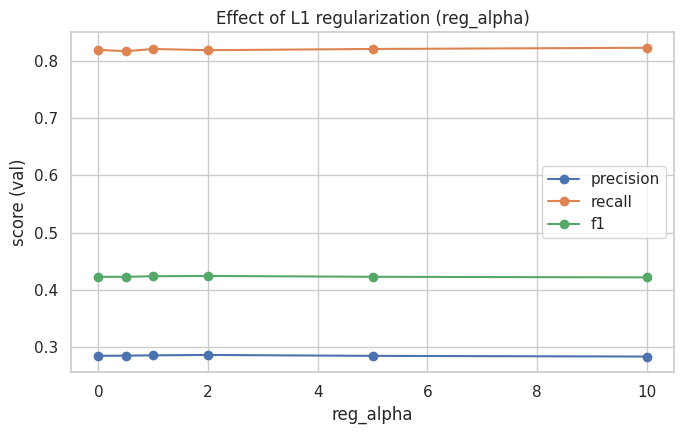

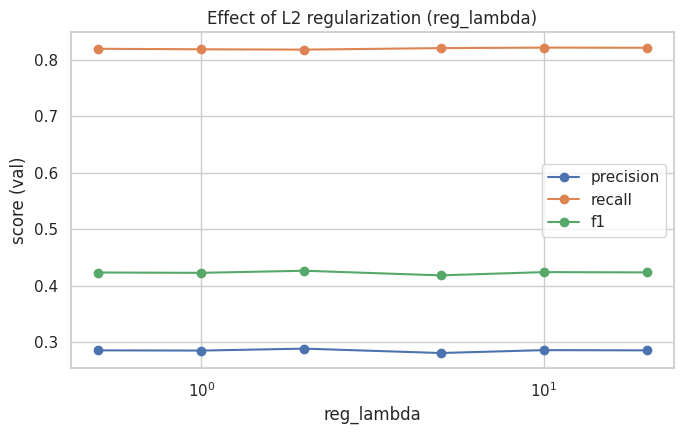

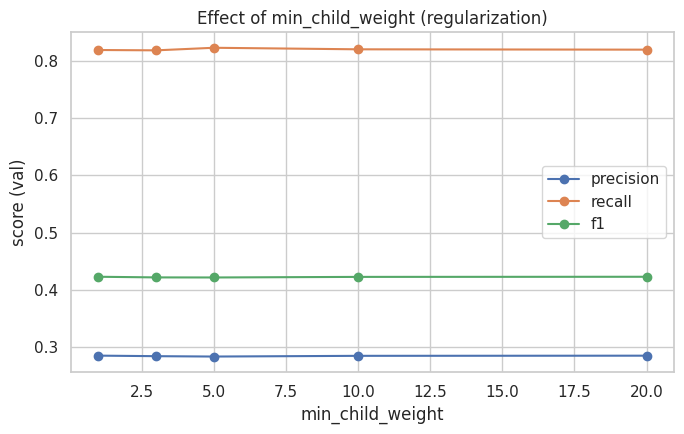

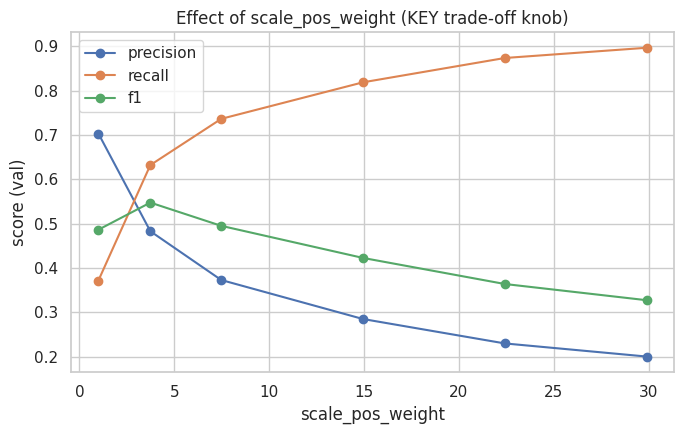

In [ ]:
if not HAS_XGB:
    raise ImportError(
        "XGBoost is not installed. "
        "Please install it first using: !pip install -q xgboost"
    )

X_tr = X_train[feature_sets[20]]
X_va = X_val[feature_sets[20]]

# L1 regularization
df_alpha = xgb_sweep(
    'reg_alpha',
    [0, 0.5, 1, 2, 5, 10],
    X_tr=X_tr,
    y_tr=y_train,
    X_va=X_va,
    y_va=y_val
)

plot_sweep(
    df_alpha,
    'reg_alpha',
    title='Effect of L1 regularization (reg_alpha)',
    tag='xgb'
)


# L2 regularization
df_lambda = xgb_sweep(
    'reg_lambda',
    [0.5, 1, 2, 5, 10, 20],
    X_tr=X_tr,
    y_tr=y_train,
    X_va=X_va,
    y_va=y_val
)

plot_sweep(
    df_lambda,
    'reg_lambda',
    logx=True,
    title='Effect of L2 regularization (reg_lambda)',
    tag='xgb'
)


# Minimum child weight
df_mcw = xgb_sweep(
    'min_child_weight',
    [1, 3, 5, 10, 20],
    X_tr=X_tr,
    y_tr=y_train,
    X_va=X_va,
    y_va=y_val
)

plot_sweep(
    df_mcw,
    'min_child_weight',
    title='Effect of min_child_weight (regularization)',
    tag='xgb'
)


# Class imbalance
spw_values = [
    1,
    pos_weight * 0.25,
    pos_weight * 0.5,
    pos_weight,
    pos_weight * 1.5,
    pos_weight * 2
]

df_spw = xgb_sweep(
    'scale_pos_weight',
    spw_values,
    X_tr=X_tr,
    y_tr=y_train,
    X_va=X_va,
    y_va=y_val
)

plot_sweep(
    df_spw,
    'scale_pos_weight',
    title='Effect of scale_pos_weight (KEY trade-off knob)',
    tag='xgb'
)

In [ ]:
import matplotlib
print(matplotlib.get_backend())
plt.figure(figsize=(7, 4))
plt.plot([1, 2, 3, 4], [10, 20, 15, 25], marker='o')
plt.title("Test Plot")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

Agg


In [ ]:
import matplotlib

print("Backend:", matplotlib.get_backend())
print("Matplotlib version:", matplotlib.__version__)

Backend: Agg
Matplotlib version: 3.10.0


In [ ]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt

matplotlib.use("module://matplotlib_inline.backend_inline")

print(matplotlib.get_backend())

module://matplotlib_inline.backend_inline


   max_depth  log_loss  accuracy  precision    recall        f1   roc_auc    pr_auc     time_s
0          3  0.335337  0.855661   0.283967  0.855815  0.426438  0.930867  0.570453   7.658422
1          4  0.320273  0.862652   0.294325  0.851918  0.437500  0.935205  0.587247  11.988793
2          5  0.306070  0.871110   0.308629  0.851319  0.453023  0.937836  0.601382  13.276843
3          6  0.292693  0.876898   0.318459  0.845024  0.462586  0.938667  0.602571  14.405269
4          8  0.260000  0.892704   0.348873  0.821043  0.489676  0.937600  0.603453  16.812814
5         10  0.220191  0.910653   0.391656  0.768285  0.518826  0.934203  0.594912  20.125303


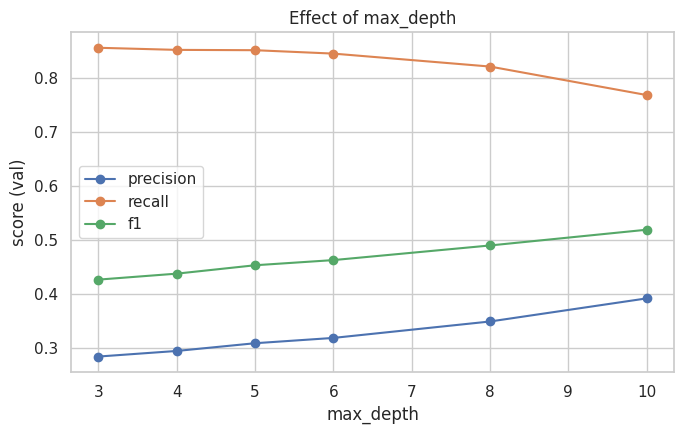

In [ ]:
df_depth = xgb_sweep(
    'max_depth',
    [3, 4, 5, 6, 8, 10],
    X_tr=X_train[feature_sets[50]],
    y_tr=y_train,
    X_va=X_val[feature_sets[50]],
    y_va=y_val
)

print(df_depth)

plot_sweep(
    df_depth,
    'max_depth',
    title='Effect of max_depth',
    tag='xgb'
)

In [ ]:
sweeps_xgb = {'max_depth': df_depth, 'learning_rate': df_lr}
if HAS_XGB:
    sweeps_xgb.update({'reg_alpha': df_alpha, 'reg_lambda': df_lambda, 'min_child_weight': df_mcw, 'scale_pos_weight': df_spw})
else:
    sweeps_xgb.update({'l2_regularization': df_alpha, 'min_samples_leaf': df_mcw})
xgb_tuned_params = dict(XGB_BASE)
if not HAS_XGB:
    xgb_tuned_params.pop('scale_pos_weight', None)
for pname, dsw in sweeps_xgb.items():
    best_val = dsw.loc[dsw['f1'].idxmax(), pname]
    xgb_tuned_params[pname] = best_val
    print(f'best {pname} (by val F1) = {best_val}')
xgb_final, xgb_val_metrics = run_trial(
    XGB_CLS,
    xgb_tuned_params,
    X_tr=X_train[feature_sets[20]],
    y_tr=y_train,
    X_va=X_val[feature_sets[20]],
    y_va=y_val
)

print('\nXGBoost tuned — val metrics:', xgb_val_metrics)

best max_depth (by val F1) = 10
best learning_rate (by val F1) = 0.3
best reg_alpha (by val F1) = 2.0
best reg_lambda (by val F1) = 2.0
best min_child_weight (by val F1) = 1
best scale_pos_weight (by val F1) = 3.7363858207038274

XGBoost tuned — val metrics: {'log_loss': 0.16395961537880915, 'accuracy': 0.941625319500827, 'precision': 0.5372409326424871, 'recall': 0.4973021582733813, 'f1': 0.5165006226650062, 'roc_auc': np.float64(0.9037106094719989), 'pr_auc': np.float64(0.5127822430502219)}


In [ ]:
if not HAS_LGBM:
    raise ImportError(
        "LightGBM is not installed. "
        "Please install it first using: !pip install -q lightgbm"
    )

LGBM_CLS = LGBMClassifier

LGBM_BASE = dict(
    n_estimators=350,
    max_depth=-1,
    num_leaves=31,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    min_child_samples=20,
    class_weight={0: 1.0, 1: float(pos_weight)},
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1
)


def lgbm_sweep(
    param_name,
    values,
    X_tr,
    y_tr,
    X_va,
    y_va
):
    rows = []

    for v in values:

        params = {
            **LGBM_BASE,
            param_name: v
        }

        t0 = time.time()

        _, m = run_trial(
            LGBM_CLS,
            params,
            X_tr=X_tr,
            y_tr=y_tr,
            X_va=X_va,
            y_va=y_va
        )

        rows.append({
            param_name: v,
            **m,
            'time_s': time.time() - t0
        })

    return pd.DataFrame(rows)


print('Model used for "LightGBM":', LGBM_CLS.__name__)


X_tr = X_train[feature_sets[20]]
X_va = X_val[feature_sets[20]]


t0 = time.time()

lgbm_base_model, base_lgbm_m = run_trial(
    LGBM_CLS,
    LGBM_BASE,
    X_tr=X_tr,
    y_tr=y_train,
    X_va=X_va,
    y_va=y_val
)

lgbm_baseline_time = time.time() - t0

print('LightGBM baseline (val):', base_lgbm_m)
print(f'Training + evaluation time: {lgbm_baseline_time:.2f} seconds')

Model used for "LightGBM": LGBMClassifier
LightGBM baseline (val): {'log_loss': 0.3242466753481557, 'accuracy': 0.8656029168546083, 'precision': 0.2930454594770533, 'recall': 0.809652278177458, 'f1': 0.4303353779972915, 'roc_auc': np.float64(0.923526908742496), 'pr_auc': np.float64(0.5696506245267944)}
Training + evaluation time: 12.78 seconds


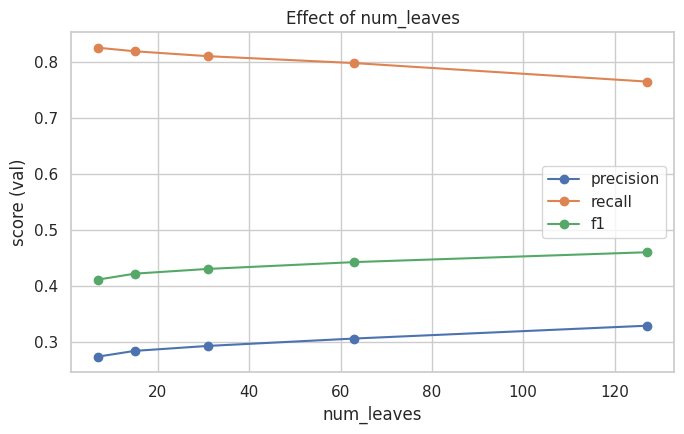

In [ ]:
df_l_leaves = lgbm_sweep(
    'num_leaves',
    [7, 15, 31, 63, 127],
    X_tr=X_train[feature_sets[20]],
    y_tr=y_train,
    X_va=X_val[feature_sets[20]],
    y_va=y_val
)

plot_sweep(
    df_l_leaves,
    'num_leaves',
    title='Effect of num_leaves',
    tag='lgbm'
)

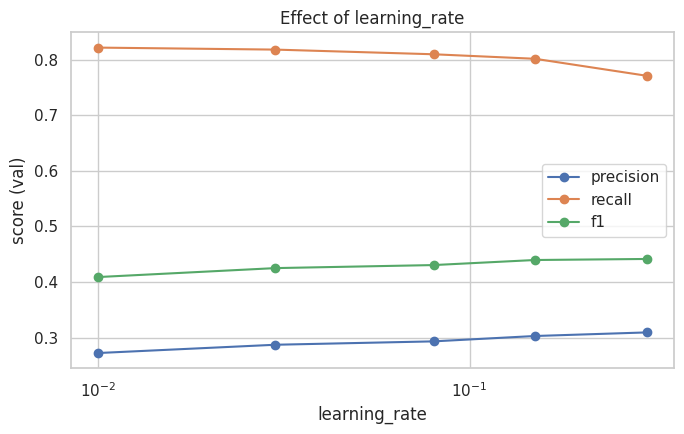

In [ ]:
df_l_lr = lgbm_sweep(
    'learning_rate',
    [0.01, 0.03, 0.08, 0.15, 0.3],
    X_tr=X_train[feature_sets[20]],
    y_tr=y_train,
    X_va=X_val[feature_sets[20]],
    y_va=y_val
)

plot_sweep(
    df_l_lr,
    'learning_rate',
    logx=True,
    title='Effect of learning_rate',
    tag='lgbm'
)

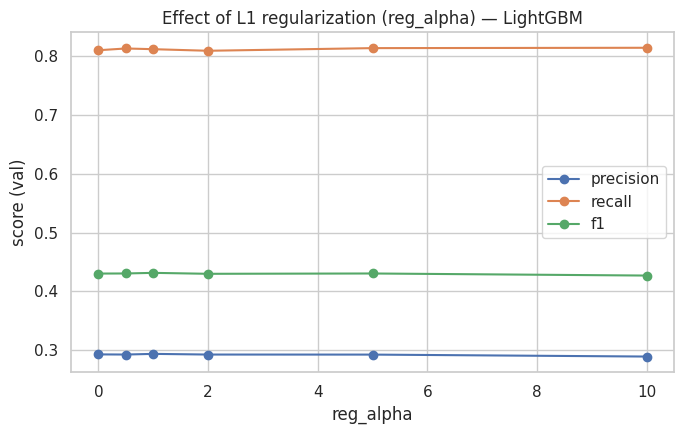

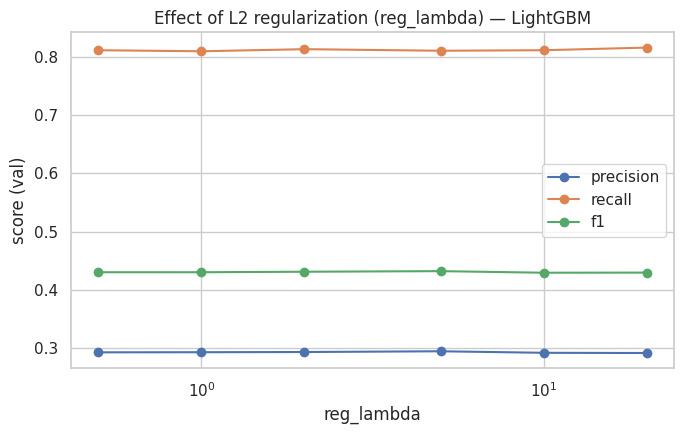

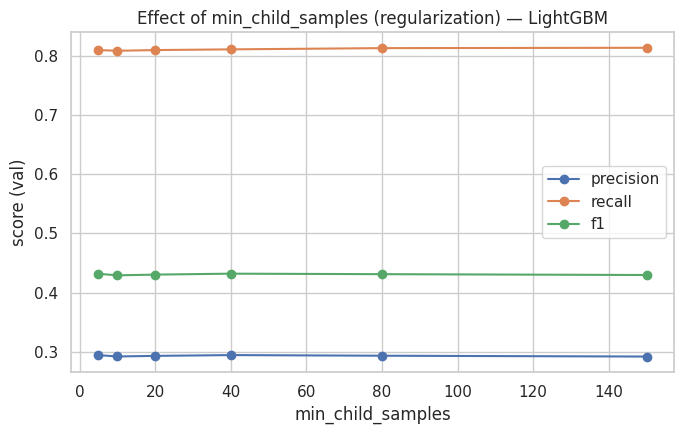

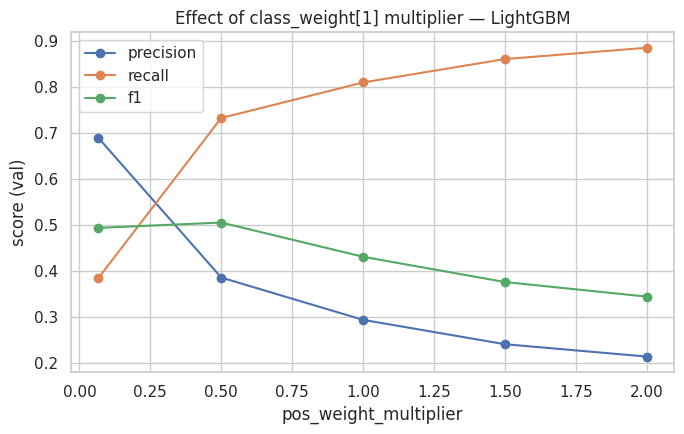

In [ ]:
df_l_alpha = lgbm_sweep(
    'reg_alpha',
    [0, 0.5, 1, 2, 5, 10],
    X_tr=X_train[feature_sets[20]],
    y_tr=y_train,
    X_va=X_val[feature_sets[20]],
    y_va=y_val
)

plot_sweep(
    df_l_alpha,
    'reg_alpha',
    title='Effect of L1 regularization (reg_alpha) — LightGBM',
    tag='lgbm'
)


df_l_lambda = lgbm_sweep(
    'reg_lambda',
    [0.5, 1, 2, 5, 10, 20],
    X_tr=X_train[feature_sets[20]],
    y_tr=y_train,
    X_va=X_val[feature_sets[20]],
    y_va=y_val
)

plot_sweep(
    df_l_lambda,
    'reg_lambda',
    logx=True,
    title='Effect of L2 regularization (reg_lambda) — LightGBM',
    tag='lgbm'
)

df_l_minchild = lgbm_sweep(
    'min_child_samples',
    [5, 10, 20, 40, 80, 150],
    X_tr=X_train[feature_sets[20]],
    y_tr=y_train,
    X_va=X_val[feature_sets[20]],
    y_va=y_val
)

plot_sweep(
    df_l_minchild,
    'min_child_samples',
    title='Effect of min_child_samples (regularization) — LightGBM',
    tag='lgbm'
)

cw_values = [
    {0: 1.0, 1: 1.0},
    {0: 1.0, 1: float(pos_weight * 0.5)},
    {0: 1.0, 1: float(pos_weight)},
    {0: 1.0, 1: float(pos_weight * 1.5)},
    {0: 1.0, 1: float(pos_weight * 2)}
]

rows = []

for cw in cw_values:
    params = {
        **LGBM_BASE,
        'class_weight': cw
    }

    _, m = run_trial(
        LGBM_CLS,
        params,
        X_tr=X_train[feature_sets[20]],
        y_tr=y_train,
        X_va=X_val[feature_sets[20]],
        y_va=y_val
    )

    rows.append({
        'pos_weight_multiplier': cw[1] / pos_weight,
        **m
    })

df_l_cw = pd.DataFrame(rows)

plot_sweep(
    df_l_cw,
    'pos_weight_multiplier',
    title='Effect of class_weight[1] multiplier — LightGBM',
    tag='lgbm'
)

In [ ]:
sweeps_lgbm = {
    'num_leaves': df_l_leaves,
    'learning_rate': df_l_lr,
    'reg_alpha': df_l_alpha,
    'reg_lambda': df_l_lambda,
    'min_child_samples': df_l_minchild
}

lgbm_tuned_params = dict(LGBM_BASE)

for pname, dsw in sweeps_lgbm.items():

    best_val = dsw.loc[dsw['f1'].idxmax(), pname]

    if pname in ('num_leaves', 'min_child_samples'):
        lgbm_tuned_params[pname] = int(best_val)
    else:
        lgbm_tuned_params[pname] = float(best_val)

    print(f'best {pname} (by val F1) = {best_val}')


if df_l_cw is not None:

    best_mult = df_l_cw.loc[
        df_l_cw['f1'].idxmax(),
        'pos_weight_multiplier'
    ]

    lgbm_tuned_params['class_weight'] = {
        0: 1.0,
        1: float(pos_weight * best_mult)
    }

    print(
        f'best class_weight multiplier (by val F1) = {best_mult}'
    )

lgbm_final, lgbm_val_metrics = run_trial(
    LGBM_CLS,
    lgbm_tuned_params,
    X_tr=X_train[feature_sets[20]],
    y_tr=y_train,
    X_va=X_val[feature_sets[20]],
    y_va=y_val
)

print('\nLightGBM tuned — val metrics:', lgbm_val_metrics)

best num_leaves (by val F1) = 127
best learning_rate (by val F1) = 0.3
best reg_alpha (by val F1) = 1.0
best reg_lambda (by val F1) = 5.0
best min_child_samples (by val F1) = 40
best class_weight multiplier (by val F1) = 0.5

LightGBM tuned — val metrics: {'log_loss': 0.1930961175037174, 'accuracy': 0.9265711923019095, 'precision': 0.4390608324439701, 'recall': 0.6166067146282974, 'f1': 0.5129036279765615, 'roc_auc': np.float64(0.9079432135235026), 'pr_auc': np.float64(0.5331997662307408)}


In [ ]:
LR_BASE = dict(
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE
)


def lr_sweep(param_name, values, X_tr, y_tr, X_va, y_va):

    rows = []

    for v in values:

        params = {
            **LR_BASE,
            param_name: v
        }

        t0 = time.time()

        _, m = run_trial(
            LogisticRegression,
            params,
            X_tr=X_tr,
            y_tr=y_tr,
            X_va=X_va,
            y_va=y_va
        )

        rows.append({
            param_name: v,
            **m,
            'time_s': time.time() - t0
        })

    return pd.DataFrame(rows)


In [ ]:
for X_split in [X_train, X_val, X_test]:
    X_split["IS_SINGLE_ENGINE"] = X_split["IS_SINGLE_ENGINE"].fillna(0)
    X_split["SMALL_AIRCRAFT_MASS"] = X_split["SMALL_AIRCRAFT_MASS"].fillna(0)

In [ ]:
print("Train NaNs:", X_train.isna().sum().sum())
print("Val NaNs:", X_val.isna().sum().sum())
print("Test NaNs:", X_test.isna().sum().sum())

Train NaNs: 521
Val NaNs: 111
Test NaNs: 117


In [ ]:
for name, X_split in [
    ("Train", X_train),
    ("Val", X_val),
    ("Test", X_test)
]:
    nan_cols = X_split.isna().sum()
    nan_cols = nan_cols[nan_cols > 0].sort_values(ascending=False)

    print(f"\n{name}:")
    print(nan_cols)


Train:
MULTIPLE_BIRDS_STRUCK    521
dtype: int64

Val:
MULTIPLE_BIRDS_STRUCK    111
dtype: int64

Test:
MULTIPLE_BIRDS_STRUCK    117
dtype: int64


In [ ]:
for X_split in [X_train, X_val, X_test]:
    X_split["MULTIPLE_BIRDS_STRUCK"] = (
        X_split["MULTIPLE_BIRDS_STRUCK"].fillna(0)
    )

In [ ]:
print("Train NaNs:", X_train.isna().sum().sum())
print("Val NaNs:", X_val.isna().sum().sum())
print("Test NaNs:", X_test.isna().sum().sum())

Train NaNs: 0
Val NaNs: 0
Test NaNs: 0


In [ ]:
_, lr_base_m = run_trial(
    LogisticRegression,
    LR_BASE,
    X_tr=X_train[feature_sets[20]],
    y_tr=y_train,
    X_va=X_val[feature_sets[20]],
    y_va=y_val
)

print('Logistic Regression baseline (val):', lr_base_m)

Logistic Regression baseline (val): {'log_loss': 0.1513999281290486, 'accuracy': 0.9468125093970832, 'precision': 0.6744827586206896, 'recall': 0.2931654676258993, 'f1': 0.40869201838696195, 'roc_auc': np.float64(0.9029094097195776), 'pr_auc': np.float64(0.49568278585084263)}


In [ ]:
X_lr_check = X_train[feature_sets[20]]

nan_counts = X_lr_check.isna().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)

print("Columns containing NaN:")
print(nan_counts)

print("\nTotal NaN values:", X_lr_check.isna().sum().sum())

Columns containing NaN:
IS_SINGLE_ENGINE       69952
SMALL_AIRCRAFT_MASS    69725
dtype: int64

Total NaN values: 139677


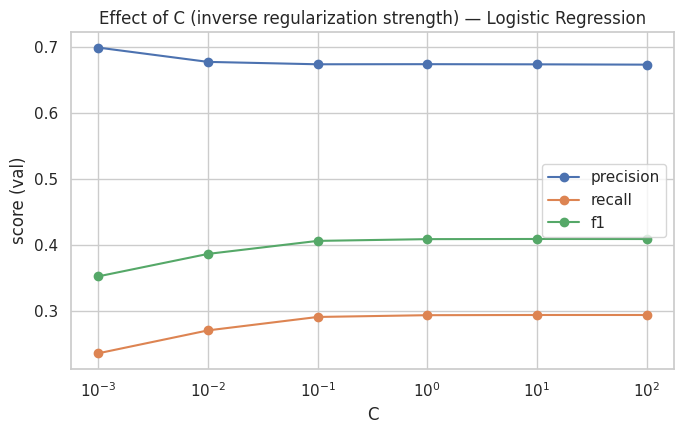

In [ ]:
df_lr_C = lr_sweep(
    'C',
    [0.001, 0.01, 0.1, 1, 10, 100],
    X_tr=X_train[feature_sets[20]],
    y_tr=y_train,
    X_va=X_val[feature_sets[20]],
    y_va=y_val
)

plot_sweep(
    df_lr_C,
    'C',
    logx=True,
    title='Effect of C (inverse regularization strength) — Logistic Regression',
    tag='lr'
)

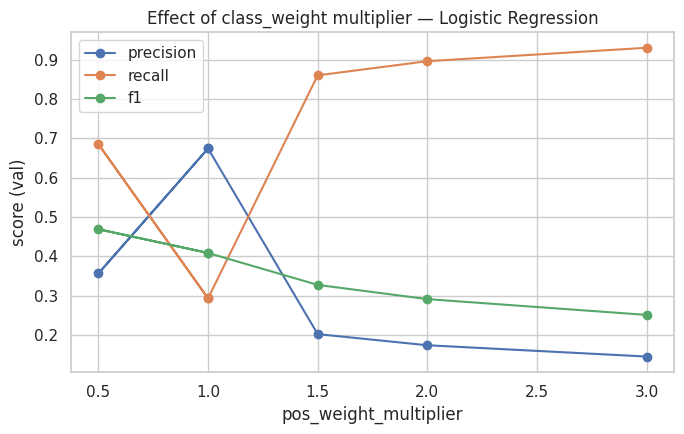

In [ ]:
cw_mult = [1, 0.5, 1.0, 1.5, 2, 3]

rows = []

for mult in cw_mult:

    cw = None if mult == 1 else {
        0: 1.0,
        1: float(pos_weight * mult)
    }

    params = {
        **LR_BASE,
        'class_weight': cw
    }

    _, m = run_trial(
        LogisticRegression,
        params,
        X_tr=X_train[feature_sets[20]],
        y_tr=y_train,
        X_va=X_val[feature_sets[20]],
        y_va=y_val
    )

    rows.append({
        'pos_weight_multiplier': mult,
        **m
    })

df_lr_cw = pd.DataFrame(rows)

plot_sweep(
    df_lr_cw,
    'pos_weight_multiplier',
    title='Effect of class_weight multiplier — Logistic Regression',
    tag='lr'
)

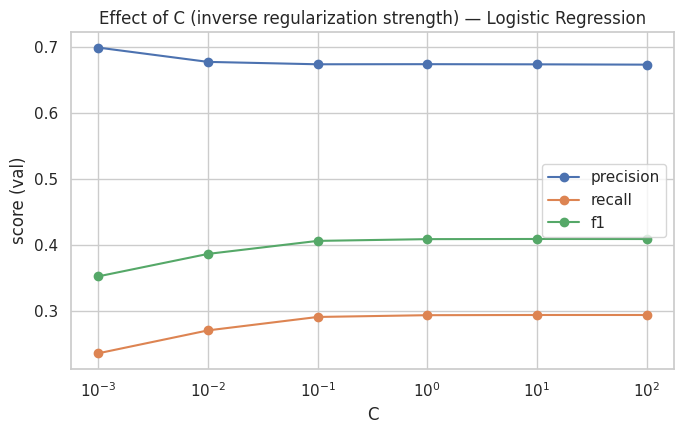

,C,log_loss,accuracy,precision,recall,f1,roc_auc,pr_auc,time_s
0,0.001,0.158585,0.945722,0.699643,0.235312,0.352176,0.893154,0.469104,3.584430
1,0.010,0.152241,0.946192,0.677953,0.270084,0.386281,0.902057,0.492753,4.892379
2,0.100,0.151419,0.946719,0.674322,0.290468,0.406034,0.902919,0.495722,7.358195
3,1.000,0.151400,0.946813,0.674483,0.293165,0.408692,0.902909,0.495683,6.673464
4,10.000,0.151392,0.946813,0.674242,0.293465,0.408939,0.902962,0.495756,5.015797
5,100.000,0.151397,0.946794,0.673778,0.293465,0.408854,0.902908,0.495665,7.914827


In [ ]:
df_lr_C = lr_sweep(
    'C',
    [0.001, 0.01, 0.1, 1, 10, 100],
    X_tr=X_train[feature_sets[20]],
    y_tr=y_train,
    X_va=X_val[feature_sets[20]],
    y_va=y_val
)

plot_sweep(
    df_lr_C,
    'C',
    logx=True,
    title='Effect of C (inverse regularization strength) — Logistic Regression',
    tag='lr'
)

display(df_lr_C)

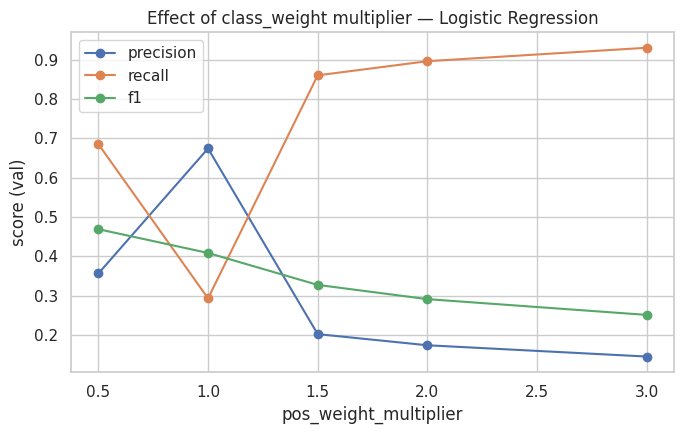

,pos_weight_multiplier,log_loss,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.5,0.271171,0.902703,0.356508,0.685552,0.469080,0.904518,0.495083
1,1.0,0.151400,0.946813,0.674483,0.293165,0.408692,0.902909,0.495683
2,1.5,0.490627,0.778304,0.202155,0.860612,0.327403,0.904931,0.494181
3,2.0,0.572839,0.726338,0.173825,0.896583,0.291194,0.904977,0.493753
4,3.0,0.707799,0.651857,0.145107,0.930755,0.251071,0.904976,0.493236


In [ ]:
cw_mult = [0.5, 1, 1.5, 2, 3]

rows = []

for mult in cw_mult:

    cw = None if mult == 1 else {
        0: 1.0,
        1: float(pos_weight * mult)
    }

    params = {
        **LR_BASE,
        'class_weight': cw
    }

    _, m = run_trial(
        LogisticRegression,
        params,
        X_tr=X_train[feature_sets[20]],
        y_tr=y_train,
        X_va=X_val[feature_sets[20]],
        y_va=y_val
    )

    rows.append({
        'pos_weight_multiplier': mult,
        **m
    })

df_lr_cw = pd.DataFrame(rows)

plot_sweep(
    df_lr_cw,
    'pos_weight_multiplier',
    title='Effect of class_weight multiplier — Logistic Regression',
    tag='lr'
)

display(df_lr_cw)

In [ ]:
# Select best hyperparameters using validation F1
best_C = df_lr_C.loc[
    df_lr_C['f1'].idxmax(),
    'C'
]

best_mult_lr = df_lr_cw.loc[
    df_lr_cw['f1'].idxmax(),
    'pos_weight_multiplier'
]


In [ ]:
# Tuned Logistic Regression
lr_tuned_params = {
    **LR_BASE,
    'C': float(best_C)
}

if best_mult_lr != 1:
    lr_tuned_params['class_weight'] = {
        0: 1.0,
        1: float(pos_weight * best_mult_lr)
    }


# Final tuned validation run
lr_final, lr_val_metrics = run_trial(
    LogisticRegression,
    lr_tuned_params,
    X_tr=X_train[feature_sets[20]],
    y_tr=y_train,
    X_va=X_val[feature_sets[20]],
    y_va=y_val
)

print(
    'best C (by val F1) =',
    best_C,
    '| best class_weight multiplier =',
    best_mult_lr
)

print(
    'Logistic Regression tuned — val metrics:',
    lr_val_metrics
)

best C (by val F1) = 10.0 | best class_weight multiplier = 0.5
Logistic Regression tuned — val metrics: {'log_loss': 0.2712265085424971, 'accuracy': 0.9027213952789054, 'precision': 0.3566084788029925, 'recall': 0.6858513189448441, 'f1': 0.4692370795734208, 'roc_auc': np.float64(0.904552639168742), 'pr_auc': np.float64(0.4951196352227736)}


                     log_loss  accuracy  precision  recall      f1  roc_auc  pr_auc
model                                                                              
XGBoost                0.1648    0.9414     0.5353  0.4955  0.5146   0.9002  0.5117
LightGBM               0.1947    0.9264     0.4381  0.6163  0.5121   0.9049  0.5325
Logistic Regression    0.2712    0.9027     0.3566  0.6859  0.4692   0.9046  0.4951


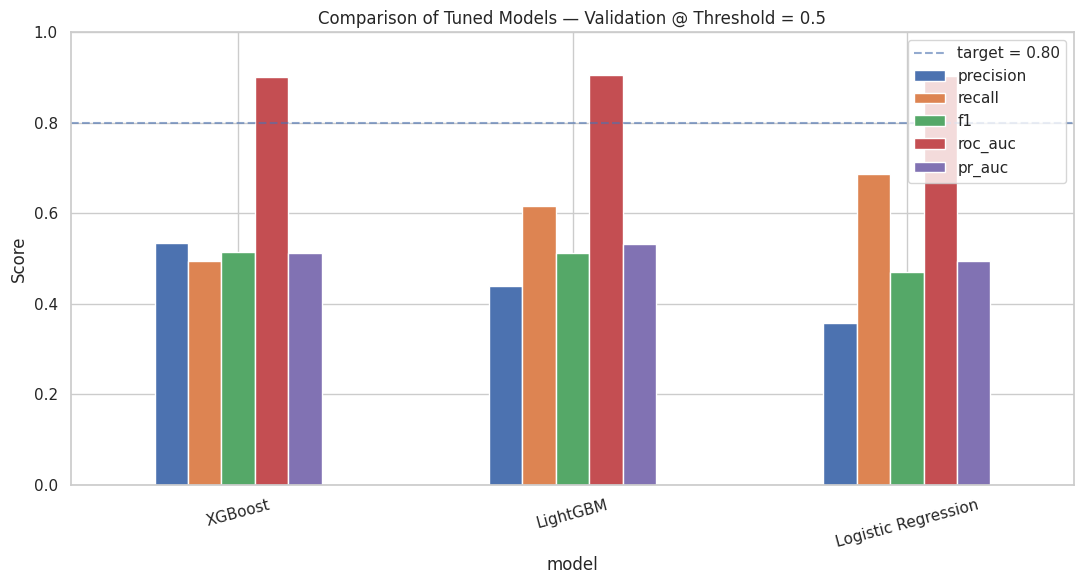

In [ ]:
final_models = {
    'XGBoost': xgb_final,
    'LightGBM': lgbm_final,
    'Logistic Regression': lr_final,
}

X_compare = X_val[feature_sets[20]]

compare_rows = []

for name, model in final_models.items():
    compare_rows.append({
        'model': name,
        **evaluate(model, X_compare, y_val)
    })

compare_df = pd.DataFrame(compare_rows).set_index('model')

print(compare_df.round(4))

compare_df[['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']].plot(
    kind='bar',
    figsize=(11, 6)
)

plt.axhline(0.8, linestyle='--', alpha=0.6, label='target = 0.80')

plt.title('Comparison of Tuned Models — Validation @ Threshold = 0.5')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('fig_final_comparison.png', dpi=100)
plt.show()

In [ ]:
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = {}

X_val_final = X_val[feature_sets[20]]

for name, model in final_models.items():

    # Get continuous scores
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_val_final)[:, 1]
    else:
        scores = model.decision_function(X_val_final)

    rows = []

    for threshold in thresholds:

        y_pred = (scores >= threshold).astype(int)

        rows.append({
            'threshold': threshold,
            'precision': precision_score(
                y_val, y_pred, zero_division=0
            ),
            'recall': recall_score(
                y_val, y_pred, zero_division=0
            ),
            'f1': f1_score(
                y_val, y_pred, zero_division=0
            )
        })

    threshold_results[name] = pd.DataFrame(rows)

    print(f"\n{name}")
    display(threshold_results[name].round(4))


XGBoost


,threshold,precision,recall,f1
0,0.10,0.2792,0.7707,0.4099
1,0.15,0.3308,0.7206,0.4534
2,0.20,0.3714,0.6712,0.4782
3,0.25,0.4070,0.6382,0.4970
4,0.30,0.4394,0.6088,0.5104
5,0.35,0.4679,0.5827,0.5190
6,0.40,0.4913,0.5525,0.5201
7,0.45,0.5147,0.5255,0.5200
8,0.50,0.5353,0.4955,0.5146
9,0.55,0.5599,0.4676,0.5096



LightGBM


,threshold,precision,recall,f1
0,0.10,0.1949,0.8726,0.3186
1,0.15,0.2285,0.8309,0.3584
2,0.20,0.2630,0.7911,0.3947
3,0.25,0.2916,0.7575,0.4211
4,0.30,0.3204,0.7269,0.4448
5,0.35,0.3548,0.6993,0.4707
6,0.40,0.3823,0.6712,0.4872
7,0.45,0.4103,0.6481,0.5025
8,0.50,0.4381,0.6163,0.5121
9,0.55,0.4683,0.5917,0.5228



Logistic Regression


,threshold,precision,recall,f1
0,0.10,0.1183,0.9643,0.2108
1,0.15,0.1436,0.9314,0.2488
2,0.20,0.1696,0.9011,0.2855
3,0.25,0.1977,0.8645,0.3218
4,0.30,0.2290,0.8291,0.3588
5,0.35,0.2651,0.7947,0.3975
6,0.40,0.2978,0.7566,0.4274
7,0.45,0.3262,0.7242,0.4498
8,0.50,0.3566,0.6859,0.4692
9,0.55,0.3831,0.6520,0.4826


In [ ]:
MIN_RECALL = 0.60

best_thresholds = []

for name, df_thr in threshold_results.items():

    # thresholds that satisfy the minimum recall requirement
    valid = df_thr[df_thr['recall'] >= MIN_RECALL]

    if len(valid) == 0:
        # if no threshold reaches the required recall,
        # choose the threshold with the highest recall
        best_idx = df_thr['recall'].idxmax()
        best_row = df_thr.loc[best_idx]

        selection_rule = 'Highest Recall (no threshold met minimum Recall)'
    else:
        # among thresholds with sufficient recall,
        # choose the one with the highest F1
        best_idx = valid['f1'].idxmax()
        best_row = valid.loc[best_idx]

        selection_rule = f'Highest F1 with Recall >= {MIN_RECALL:.2f}'

    best_thresholds.append({
        'model': name,
        'best_threshold': best_row['threshold'],
        'precision': best_row['precision'],
        'recall': best_row['recall'],
        'f1': best_row['f1'],
        'selection_rule': selection_rule
    })

best_threshold_df = pd.DataFrame(best_thresholds)

display(best_threshold_df.round(4))

,model,best_threshold,precision,recall,f1,selection_rule
0,XGBoost,0.3,0.4394,0.6088,0.5104,Highest F1 with Recall >= 0.60
1,LightGBM,0.5,0.4381,0.6163,0.5121,Highest F1 with Recall >= 0.60
2,Logistic Regression,0.6,0.4106,0.6139,0.4921,Highest F1 with Recall >= 0.60


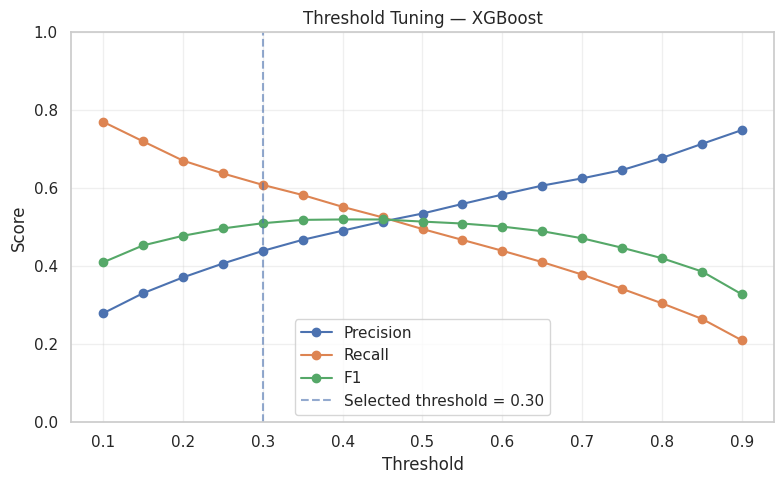

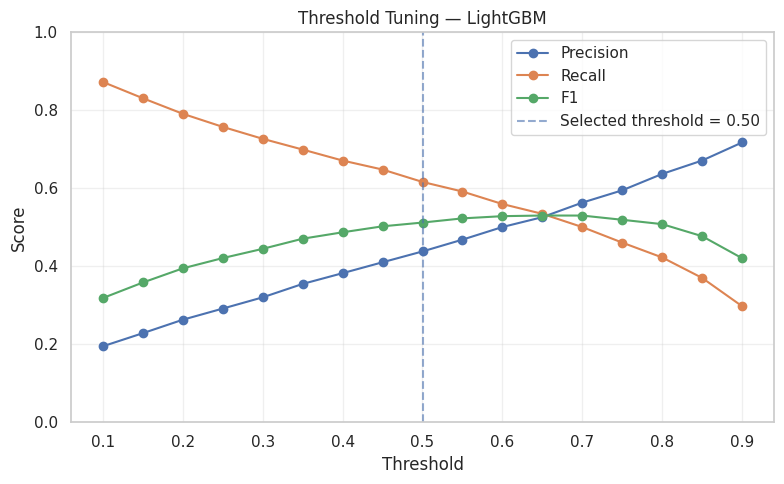

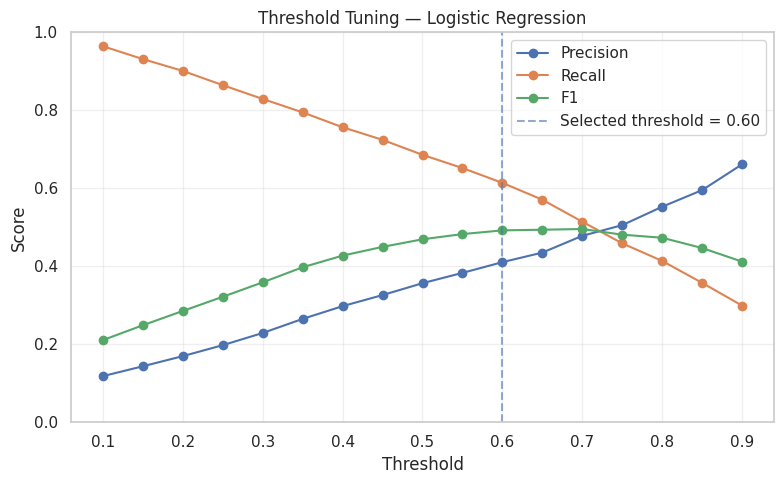

In [ ]:
for name, df_thr in threshold_results.items():

    best_threshold = best_threshold_df.loc[
        best_threshold_df['model'] == name,
        'best_threshold'
    ].iloc[0]

    plt.figure(figsize=(8, 5))

    plt.plot(
        df_thr['threshold'],
        df_thr['precision'],
        marker='o',
        label='Precision'
    )

    plt.plot(
        df_thr['threshold'],
        df_thr['recall'],
        marker='o',
        label='Recall'
    )

    plt.plot(
        df_thr['threshold'],
        df_thr['f1'],
        marker='o',
        label='F1'
    )

    plt.axvline(
        best_threshold,
        linestyle='--',
        alpha=0.6,
        label=f'Selected threshold = {best_threshold:.2f}'
    )

    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.title(f'Threshold Tuning — {name}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        f'fig_threshold_{name.lower().replace(" ", "_")}.png',
        dpi=100
    )

    plt.show()

In [ ]:
threshold_compare_rows = []

for name, model in final_models.items():

    best_threshold = best_threshold_df.loc[
        best_threshold_df['model'] == name,
        'best_threshold'
    ].iloc[0]

    scores = model.predict_proba(
        X_val[feature_sets[20]]
    )[:, 1]

    y_pred = (scores >= best_threshold).astype(int)

    threshold_compare_rows.append({
        'model': name,
        'threshold': best_threshold,
        'precision': precision_score(
            y_val, y_pred, zero_division=0
        ),
        'recall': recall_score(
            y_val, y_pred, zero_division=0
        ),
        'f1': f1_score(
            y_val, y_pred, zero_division=0
        ),
        'roc_auc': roc_auc_score(
            y_val, scores
        ),
        'pr_auc': average_precision_score(
            y_val, scores
        )
    })

threshold_compare_df = pd.DataFrame(
    threshold_compare_rows
).set_index('model')

display(threshold_compare_df.round(4))

,threshold,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
XGBoost,0.3,0.4394,0.6088,0.5104,0.9002,0.5117
LightGBM,0.5,0.4381,0.6163,0.5121,0.9049,0.5325
Logistic Regression,0.6,0.4106,0.6139,0.4921,0.9046,0.4951


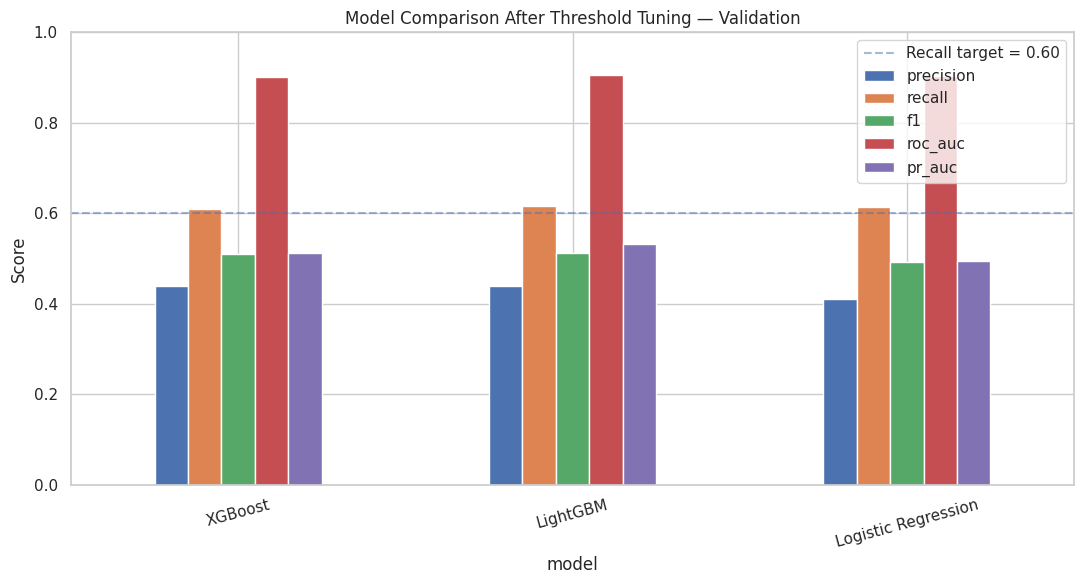

In [ ]:
threshold_compare_df[
    ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
].plot(
    kind='bar',
    figsize=(11, 6)
)

plt.axhline(
    0.60,
    linestyle='--',
    alpha=0.5,
    label='Recall target = 0.60'
)

plt.title(
    'Model Comparison After Threshold Tuning — Validation'
)

plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()

plt.savefig(
    'fig_model_comparison_after_threshold_tuning.png',
    dpi=100
)

plt.show()

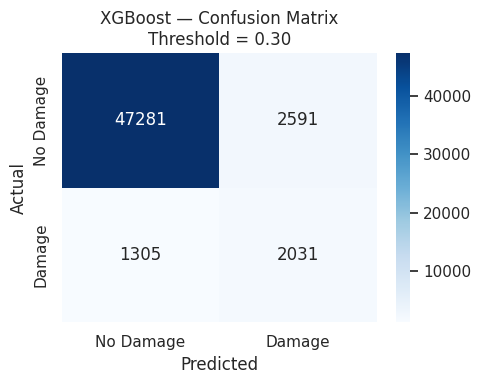

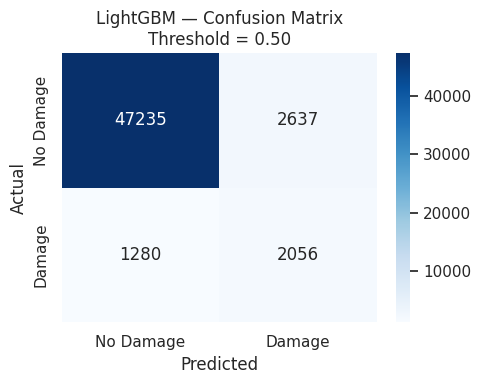

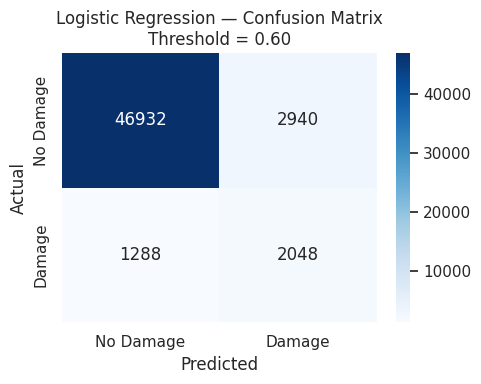

In [ ]:
for name, model in final_models.items():

    best_threshold = best_threshold_df.loc[
        best_threshold_df['model'] == name,
        'best_threshold'
    ].iloc[0]

    scores = model.predict_proba(
        X_val[feature_sets[20]]
    )[:, 1]

    y_pred = (scores >= best_threshold).astype(int)

    cm = confusion_matrix(y_val, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No Damage', 'Damage'],
        yticklabels=['No Damage', 'Damage']
    )

    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(
        f'{name} — Confusion Matrix\n'
        f'Threshold = {best_threshold:.2f}'
    )

    plt.tight_layout()

    plt.savefig(
        f'fig_cm_{name.lower().replace(" ", "_")}.png',
        dpi=100
    )

    plt.show()

In [ ]:
for name, model in final_models.items():

    best_threshold = best_threshold_df.loc[
        best_threshold_df['model'] == name,
        'best_threshold'
    ].iloc[0]

    scores = model.predict_proba(
        X_val[feature_sets[20]]
    )[:, 1]

    y_pred = (scores >= best_threshold).astype(int)

    print('\n' + '=' * 70)
    print(f'{name}')
    print(f'Selected Threshold: {best_threshold:.2f}')
    print('=' * 70)

    print(
        classification_report(
            y_val,
            y_pred,
            target_names=['No Damage', 'Damage'],
            digits=4,
            zero_division=0
        )
    )


XGBoost
Selected Threshold: 0.30
              precision    recall  f1-score   support

   No Damage     0.9731    0.9480    0.9604     49872
      Damage     0.4394    0.6088    0.5104      3336

    accuracy                         0.9268     53208
   macro avg     0.7063    0.7784    0.7354     53208
weighted avg     0.9397    0.9268    0.9322     53208


LightGBM
Selected Threshold: 0.50
              precision    recall  f1-score   support

   No Damage     0.9736    0.9471    0.9602     49872
      Damage     0.4381    0.6163    0.5121      3336

    accuracy                         0.9264     53208
   macro avg     0.7059    0.7817    0.7362     53208
weighted avg     0.9400    0.9264    0.9321     53208


Logistic Regression
Selected Threshold: 0.60
              precision    recall  f1-score   support

   No Damage     0.9733    0.9410    0.9569     49872
      Damage     0.4106    0.6139    0.4921      3336

    accuracy                         0.9205     53208
   macro avg 

In [ ]:
selected_thresholds = dict(
    zip(
        best_threshold_df['model'],
        best_threshold_df['best_threshold']
    )
)

print(selected_thresholds)

{'XGBoost': 0.30000000000000004, 'LightGBM': 0.5000000000000001, 'Logistic Regression': 0.6000000000000002}


In [ ]:
final_test_rows = []

X_test_final = X_test[feature_sets[20]]

for name, model in final_models.items():

    threshold = selected_thresholds[name]

    scores = model.predict_proba(X_test_final)[:, 1]

    y_pred = (scores >= threshold).astype(int)

    final_test_rows.append({
        'model': name,
        'threshold': threshold,
        'precision': precision_score(
            y_test, y_pred, zero_division=0
        ),
        'recall': recall_score(
            y_test, y_pred, zero_division=0
        ),
        'f1': f1_score(
            y_test, y_pred, zero_division=0
        ),
        'roc_auc': roc_auc_score(
            y_test, scores
        ),
        'pr_auc': average_precision_score(
            y_test, scores
        ),
        'accuracy': accuracy_score(
            y_test, y_pred
        ),
        'log_loss': log_loss(
            y_test, scores,
            labels=[0, 1]
        )
    })

final_test_df = pd.DataFrame(
    final_test_rows
).set_index('model')

display(final_test_df.round(4))

,threshold,precision,recall,f1,roc_auc,pr_auc,accuracy,log_loss
model,,,,,,,,
XGBoost,0.3,0.4288,0.5960,0.4988,0.8960,0.5128,0.9249,0.1664
LightGBM,0.5,0.4388,0.6101,0.5105,0.9019,0.5305,0.9266,0.1955
Logistic Regression,0.6,0.4069,0.6185,0.4908,0.9047,0.5038,0.9195,0.2719


In [ ]:
final_test_rows = []

X_test_final = X_test[feature_sets[20]]

for name, model in final_models.items():

    threshold = selected_thresholds[name]

    scores = model.predict_proba(X_test_final)[:, 1]

    y_pred = (scores >= threshold).astype(int)

    final_test_rows.append({
        'model': name,
        'threshold': threshold,
        'precision': precision_score(
            y_test, y_pred, zero_division=0
        ),
        'recall': recall_score(
            y_test, y_pred, zero_division=0
        ),
        'f1': f1_score(
            y_test, y_pred, zero_division=0
        ),
        'roc_auc': roc_auc_score(
            y_test, scores
        ),
        'pr_auc': average_precision_score(
            y_test, scores
        ),
        'accuracy': accuracy_score(
            y_test, y_pred
        ),
        'log_loss': log_loss(
            y_test, scores,
            labels=[0, 1]
        )
    })

final_test_df = pd.DataFrame(
    final_test_rows
).set_index('model')

display(final_test_df.round(4))

,threshold,precision,recall,f1,roc_auc,pr_auc,accuracy,log_loss
model,,,,,,,,
XGBoost,0.3,0.4288,0.5960,0.4988,0.8960,0.5128,0.9249,0.1664
LightGBM,0.5,0.4388,0.6101,0.5105,0.9019,0.5305,0.9266,0.1955
Logistic Regression,0.6,0.4069,0.6185,0.4908,0.9047,0.5038,0.9195,0.2719
